# humidity

In [1]:
import pandas as pd

In [2]:
district = 'Feni'
df_district = pd.read_csv(f'../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv')

df_district = df_district.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'humidity']
df_district = df_district[desired_colmn]

df_district = df_district.dropna()

df_district.head()

,day,month,year,humidity
0,1,1,1980,75.7
1,2,1,1980,65.0
2,3,1,1980,75.2
3,4,1,1980,70.4
4,5,1,1980,77.1


Date range: 2014-01-01 to 2024-12-31


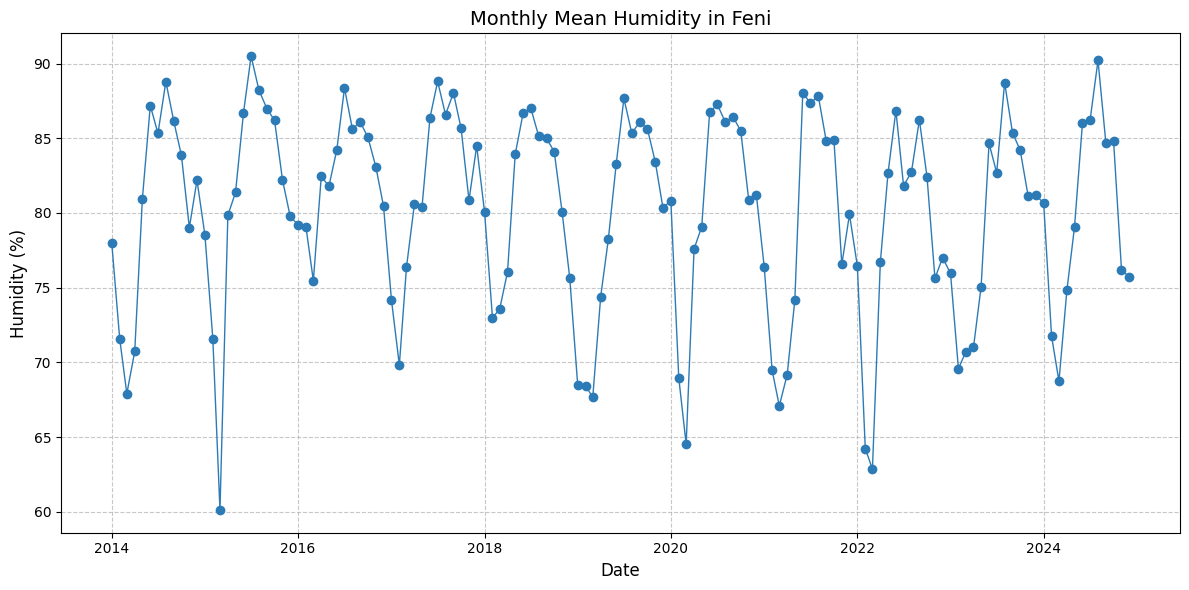

In [3]:
import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])

# # show date range
# min_date = df_district['date'].min()
# max_date = df_district['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")

# 2010-2024 dile 83% r2 lightgbm
# 2014- 2024 dile 82% R2
# 2018-2024 dile 52% R2 xgboost

# filter data for custom date range: 2020 to 2024
df_district = df_district[
    (df_district['date'] >= '2014-01-01') & (df_district['date'] <= '2024-12-31')
]
custom_range_df = df_district.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()

df_district['date'] = pd.to_datetime(df_district['date'])
df_district.set_index('date', inplace=True)

df_monthly_hum = df_district['humidity'].resample('MS').mean()
# Fill missing gaps using linear interpolation (common for weather data)
df_monthly_hum = df_monthly_hum.interpolate(method='linear')

print(f"Date range: {min_date.date()} to {max_date.date()}")

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(df_monthly_hum, marker='o', linestyle='-', color='#2c7bb6', linewidth=1)
plt.title(f'Monthly Mean Humidity in {district}', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) 

# pchip: Piecewise Cubic Hermite Interpolating Polynomial

df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_hum.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [5]:
df_monthly_hum.head()

,date,humidity
0,2014-01-01,77.977419
1,2014-02-01,71.592857
2,2014-03-01,67.906452
3,2014-04-01,70.746667
4,2014-05-01,80.961290


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['humidity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


## RF hum

In [7]:
# param_grid_rf = {
#     'n_estimators': [100, 300, 500],
#     'max_depth': [3, 4, 6],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [7, 12, 20],   # Equivalent to min_child_samples
#     'max_features': [0.7, 'sqrt'],      # Feature bagging
#     'max_samples': [0.7, 0.8],          # Observation bagging
#     'bootstrap': [True]
# }

In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Humidity Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Humidity Prediction (Test) ===
R²          : 0.7464
RMSE        : 3.208 °C
MSE         : 10.2899
Accuracy (± tolerance):
  ±0.5 °C :  7.41%
  ±1.0 °C : 18.52%
  ±2.0 °C : 51.85%
  ±3.0 °C : 70.37%

=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.7006  (±0.1324)
Scores  : [0.4852 0.62   0.8146 0.7405 0.8427]

=== Feature Importances (Top 10) ===
 feature  importance
   sin_1    0.741165
   cos_1    0.170846
   sin_2    0.029931
year_val    0.025690
   sin_3    0.012427
   cos_2    0.009973
   cos_3    0.009969


## XGBoost hum

In [9]:
# param_grid_xgb = {
#     'n_estimators': [100, 500],
#     'learning_rate': [0.01, 0.05],
#     'max_depth': [3, 4, 6],
#     'min_child_weight': [1, 5, 10],     # High values stop noise-chasing
#     'gamma': [0.1, 1, 5],               # Minimum loss reduction to split
#     'reg_alpha': [0.5, 1, 5],           # L1 regularization
#     'reg_lambda': [0.5, 1, 5],          # L2 regularization
#     'subsample': [0.7],
#     'colsample_bytree': [0.7]
# }

In [10]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.8539
xgboost_MSE  : 5.9282
xgboost_RMSE : 2.4348
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 11.11%
  ±1.0°C : 29.63%
  ±2.0°C : 59.26%
  ±3.0°C : 77.78%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.4864  |  Std : 0.3556

==== Top Feature Importances ====
 feature  importance
   sin_1    0.328189
   sin_2    0.226749
   cos_1    0.181515
   cos_2    0.082689
   cos_3    0.077998
   sin_3    0.061538
year_val    0.041322


## light gbm hum

In [11]:
# param_grid = {
#     'n_estimators': [100, 500],
#     'learning_rate': [0.01, 0.05],
#     'max_depth': [3, 4, 6],
#     'num_leaves': [5, 10, 20],
#     'min_child_samples': [10, 15, 25], # Higher helps with Bogra-style noise
#     'reg_alpha': [0.5, 1, 5],          # Increased L1 for sparsity
#     'reg_lambda': [0.5, 1, 5],         # Increased L2 for weight decay
#     'subsample': [0.7],
#     'colsample_bytree': [0.7]
# }

In [12]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) ====
LGB_R^2  : 0.8429
LGB_MSE  : 6.3714
LGB_RMSE : 2.5242
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 18.52%
  ±1.0°C : 25.93%
  ±2.0°C : 55.56%
  ±3.0°C : 66.67%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.6019  |  Std : 0.2140

==== Top Feature Importances ====
 feature   importance
   sin_1 82300.390801
   cos_1 29533.150473
year_val 21839.190982
   sin_2 14377.798190
   sin_3 12564.188568
   cos_3  8593.076039
   cos_2  6007.873990


## cat boost hum

In [13]:
# param_grid_cat = {
#     'iterations': [100, 500],           # Equivalent to n_estimators
#     'learning_rate': [0.01, 0.05],
#     'depth': [3, 4, 6],                 # Equivalent to max_depth
#     'l2_leaf_reg': [1, 5, 10, 20],      # High L2 to smooth the curve
#     'random_strength': [1, 2, 5],       # Adds noise to splits to prevent memorization
#     'bagging_temperature': [0.5, 1.0],  # Bayesian bagging control
#     'border_count': [32, 64],           # Fewer bins = more generalization
#     'grow_policy': ['SymmetricTree'],   # Usually most robust for small data
#     'verbose': [0]
# }

In [14]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.8281
CatBoost_MSE  : 6.9723
CatBoost_RMSE : 2.6405
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 11.11%
  ±1.0°C : 18.52%
  ±2.0°C : 59.26%
  ±3.0°C : 70.37%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.6011  |  Std : 0.2171

==== Top Feature Importances ====
 feature  importance
   sin_1   50.048639
   cos_1   13.769981
year_val    9.451465
   sin_2    9.353705
   sin_3    6.715637
   cos_2    5.706455
   cos_3    4.954118


## comparision humidity

In [15]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2    CV R2       MSE     RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.746353 0.700607 10.289868 3.207782        7.407407       18.518519       51.851852       70.370370
      XGBoost 0.853868 0.486439  5.928230 2.434796       11.111111       29.629630       59.259259       77.777778
     LightGBM 0.842943 0.601861  6.371418 2.524167       18.518519       25.925926       55.555556       66.666667
     CatBoost 0.828130 0.601056  6.972339 2.640519       11.111111       18.518519       59.259259       70.370370


In [16]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
2       LightGBM  0.842943  0.601861  0.241082         0.681427  Overfit Risk
3       CatBoost  0.828130  0.601056  0.227074         0.557981  Overfit Risk
1        XGBoost  0.853868  0.486439  0.367429         0.550000  Overfit Risk
0  Random Forest  0.746353  0.700607  0.045745         0.450000        Robust


## predicting with best model for two years humidity

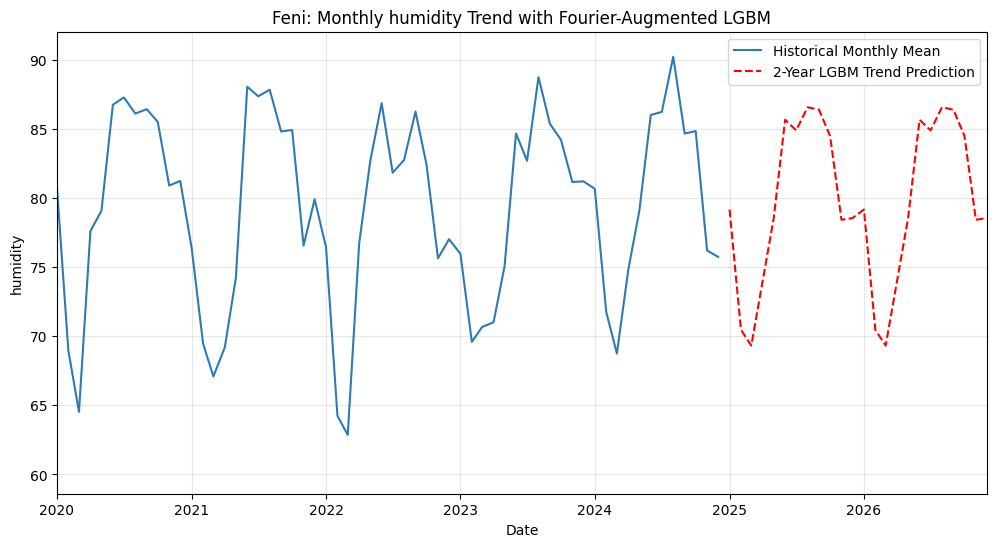

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb


# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_hum.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['humidity']

# 4. Train Random Forest [cite: 145, 146]
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)


# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_hum = lgb_model.predict(future_df[FEATURES])


# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_hum, label='2-Year LGBM Trend Prediction', linestyle='--', color='red')
plt.title('Feni: Monthly humidity Trend with Fourier-Augmented LGBM')
plt.xlabel('Date')
plt.ylabel('humidity')
plt.legend()
plt.grid(True, alpha=0.3)
# Set the start date to Jan 1st, 2023
plt.xlim(pd.Timestamp('2020-01-01'), future_dates.max())
plt.show()

<>:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:24: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:24: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_26752\1657491401.py:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')
C:\Users\User\AppData\Local\Temp\ipykernel_26752\1657491401.py:24: SyntaxWarning: "\p" is 

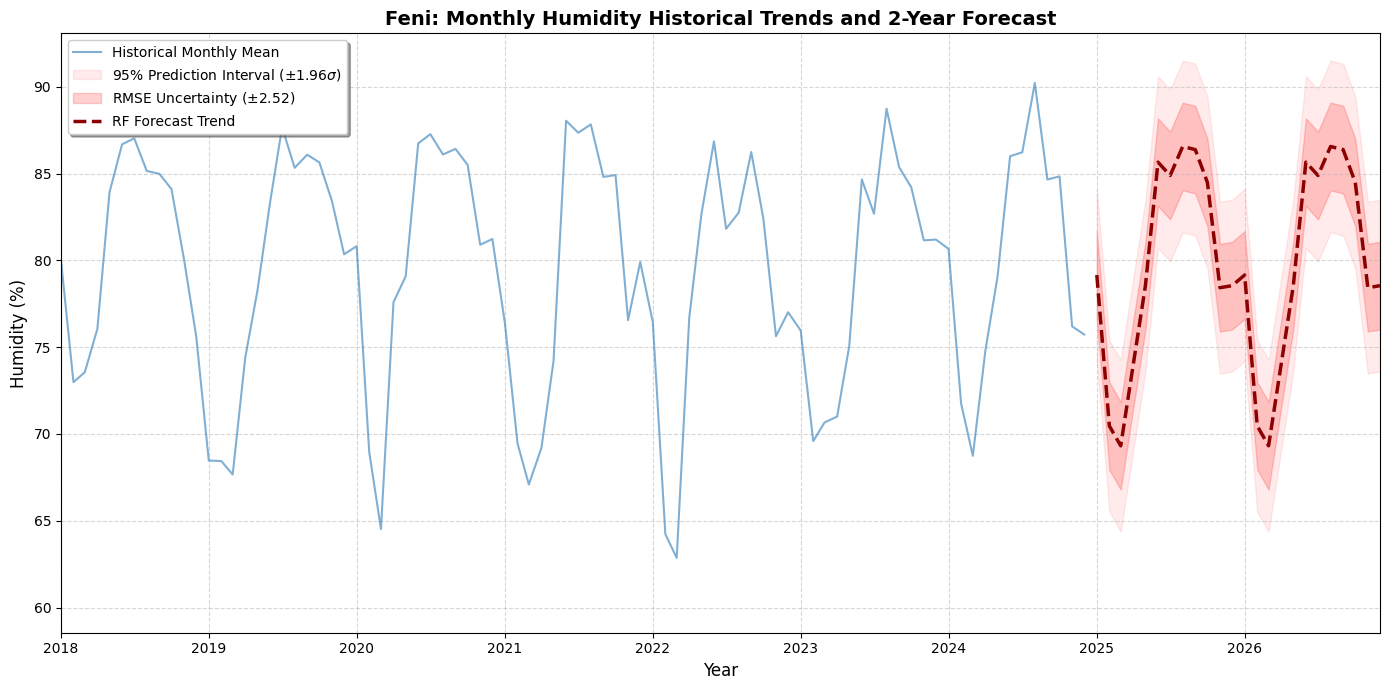

In [18]:
# 5. Predict 2 Years Future with Empirical Validation
mean_preds = lgb_model.predict(future_df[FEATURES])

best_model_rmse = 2.5242 
upper_95 = mean_preds + (1.96 * best_model_rmse)
lower_95 = mean_preds - (1.96 * best_model_rmse)
upper_68 = mean_preds + best_model_rmse
lower_68 = mean_preds - best_model_rmse

# 2. Setup the Plot
plt.figure(figsize=(14, 7))

# 3. Plot Historical Data (The Context)
# Ensure df_features['date'] is in datetime format
plt.plot(df_features['date'], y, label='Historical Monthly Mean', 
         color='#2c7bb6', alpha=0.6, linewidth=1.5)

# 4. Plot the 95% Confidence Interval (The Outer Cloud)
plt.fill_between(future_dates, lower_95, upper_95, 
                 color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')

# 5. Plot the 68% Confidence Interval (The RMSE Cloud)
plt.fill_between(future_dates, lower_68, upper_68, 
                 color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${best_model_rmse:.2f})')

# 6. Plot the Future Prediction Mean (The Trend)
plt.plot(future_dates, mean_preds, label='RF Forecast Trend', 
         linestyle='--', color='darkred', lw=2.5)

# 7. Journal Formatting & Aesthetics
plt.title(f'{district}: Monthly Humidity Historical Trends and 2-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)

# Set the x-axis to start slightly before the forecast for better perspective
# Adjust '2018-01-01' to whatever date makes your historical trend visible
plt.xlim(pd.Timestamp('2018-01-01'), future_dates.max()) 

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

In [19]:
# create the dataframe of the predicted values of 2025 and 2026
df_predictions_humidity = pd.DataFrame({
    'date': future_dates,
    'predicted_humidity': predictions_hum
})


In [20]:
df_predictions_humidity

,date,predicted_humidity
0,2025-01-01,79.155959
1,2025-02-01,70.462287
2,2025-03-01,69.319944
3,2025-04-01,74.006810
4,2025-05-01,78.541137
5,2025-06-01,85.652517
6,2025-07-01,84.884579
7,2025-08-01,86.555326
8,2025-09-01,86.376893
9,2025-10-01,84.482786


# temperature

In [21]:
import pandas as pd

In [22]:
df_district = pd.read_csv(f'../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv')

df_district = df_district.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'temperature(degree C)']
df_district = df_district[desired_colmn]

df_district = df_district.dropna()

df_district.head()

,day,month,year,temperature(degree C)
0,1,1,1980,20.9
1,2,1,1980,22.4
2,3,1,1980,20.4
3,4,1,1980,20.7
4,5,1,1980,20.8


Date range: 2014-01-01 to 2024-12-31


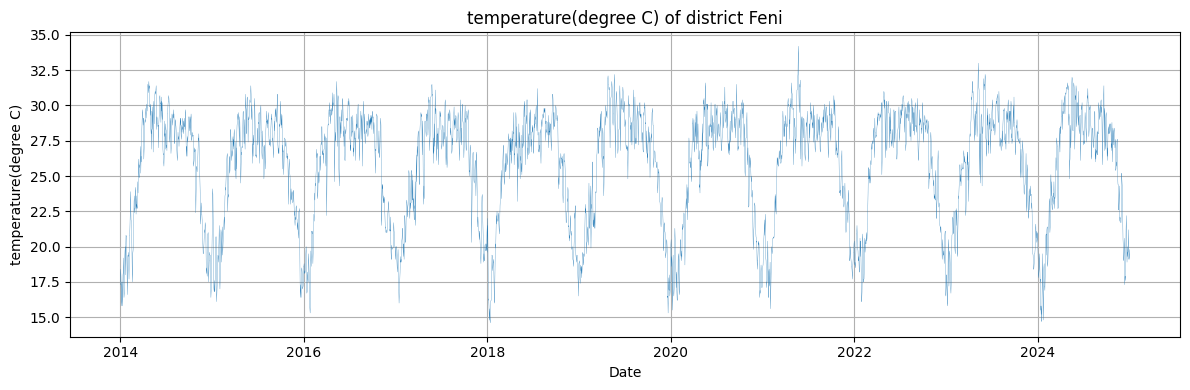

In [23]:
import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])

# # show date range
# min_date = df_district['date'].min()
# max_date = df_district['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")


# 1980-2024 dile 92% R2 xgboost
# 2010-2024 dile 96.7% r2 rf
# 2014/2024 filr 95% r2 xgboost
# filter data for custom date range: 2020 to 2024
df_district = df_district[
    (df_district['date'] >= '2014-01-01') & (df_district['date'] <= '2024-12-31')
]
custom_range_df = df_district.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()
print(f"Date range: {min_date.date()} to {max_date.date()}")

# plot daily temperature time series
plt.figure(figsize=(12, 4))
plt.plot(df_district['date'], df_district['temperature(degree C)'], linewidth=0.2)
plt.xlabel('Date')
plt.ylabel('temperature(degree C)')
plt.title(f'temperature(degree C) of district {district}')
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna() # Fill missing gaps using linear interpolation (common for weather data)

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_temp.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['temperature(degree C)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


## RF temp

In [26]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Humidity Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Humidity Prediction (Test) ===
R²          : 0.9353
RMSE        : 0.917 °C
MSE         : 0.8411
Accuracy (± tolerance):
  ±0.5 °C : 40.74%
  ±1.0 °C : 74.07%
  ±2.0 °C : 96.30%
  ±3.0 °C : 100.00%

=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.7485  (±0.2109)
Scores  : [0.3435 0.7554 0.8219 0.9159 0.906 ]

=== Feature Importances (Top 10) ===
 feature  importance
   cos_1    0.729853
   sin_1    0.137376
   sin_2    0.094237
   sin_3    0.017578
   cos_2    0.007637
   cos_3    0.007224
year_val    0.006095


## XGBoost temp

In [27]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.9525
xgboost_MSE  : 0.6179
xgboost_RMSE : 0.7861
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 44.44%
  ±1.0°C : 85.19%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.9477  |  Std : 0.0127

==== Top Feature Importances ====
 feature  importance
   cos_1    0.514170
   sin_2    0.171503
   sin_1    0.159592
   sin_3    0.075281
   cos_3    0.049640
   cos_2    0.023415
year_val    0.006400


## light gbm temp

In [28]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) ====
LGB_R^2  : 0.9546
LGB_MSE  : 0.5911
LGB_RMSE : 0.7689
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 33.33%
  ±1.0°C : 81.48%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.9500  |  Std : 0.0094

==== Top Feature Importances ====
 feature   importance
   cos_1 24367.933108
   sin_1 10248.903909
   sin_2  5475.641561
   sin_3  3568.599251
   cos_2  2895.561197
   cos_3  1391.025850
year_val   960.624207


## cat boost temp

In [29]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.9523
CatBoost_MSE  : 0.6207
CatBoost_RMSE : 0.7879
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 40.74%
  ±1.0°C : 77.78%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.9467  |  Std : 0.0168

==== Top Feature Importances ====
 feature  importance
   cos_1   60.002786
   sin_1   13.094624
   sin_2   10.515972
   sin_3    6.170865
   cos_3    4.400640
   cos_2    3.848774
year_val    1.966338


## comparision temp

In [30]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2    CV R2      MSE     RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.935331 0.748532 0.841149 0.917142       40.740741       74.074074       96.296296           100.0
      XGBoost 0.952491 0.947652 0.617945 0.786095       44.444444       85.185185      100.000000           100.0
     LightGBM 0.954551 0.950050 0.591149 0.768862       33.333333       81.481481      100.000000           100.0
     CatBoost 0.952275 0.946730 0.620750 0.787877       40.740741       77.777778      100.000000           100.0


In [31]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
2       LightGBM  0.954551  0.950050  0.004501         0.966667        Robust
1        XGBoost  0.952491  0.947652  0.004839         0.946615        Robust
3       CatBoost  0.952275  0.946730  0.005545         0.872822        Robust
0  Random Forest  0.935331  0.748532  0.186798         0.000000  Overfit Risk


## predicting with best model for two years temperature

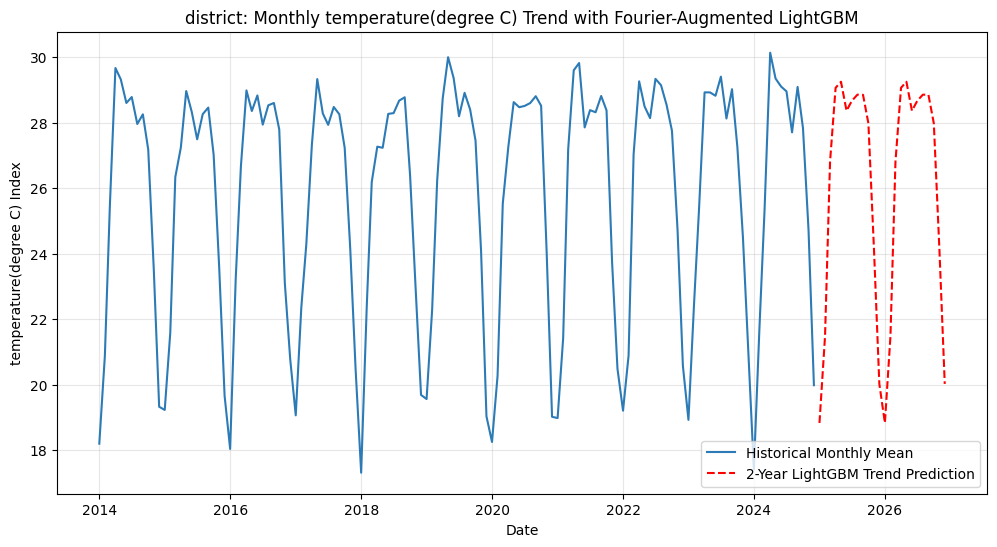

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['temperature(degree C)']

# 4. Train Random Forest [cite: 145, 146]
lgb_model = lgb.LGBMRegressor(
     n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset

)
lgb_model.fit(X_train, y_train)

# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_temp = lgb_model.predict(future_df[FEATURES])

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_temp, label='2-Year LightGBM Trend Prediction', linestyle='--', color='red')
plt.title('district: Monthly temperature(degree C) Trend with Fourier-Augmented LightGBM')
plt.xlabel('Date')
plt.ylabel('temperature(degree C) Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_26752\1513175567.py:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')
C:\Users\User\AppData\Local\Temp\ipykernel_26752\1513175567.py:25: SyntaxWarning: "\p" is 

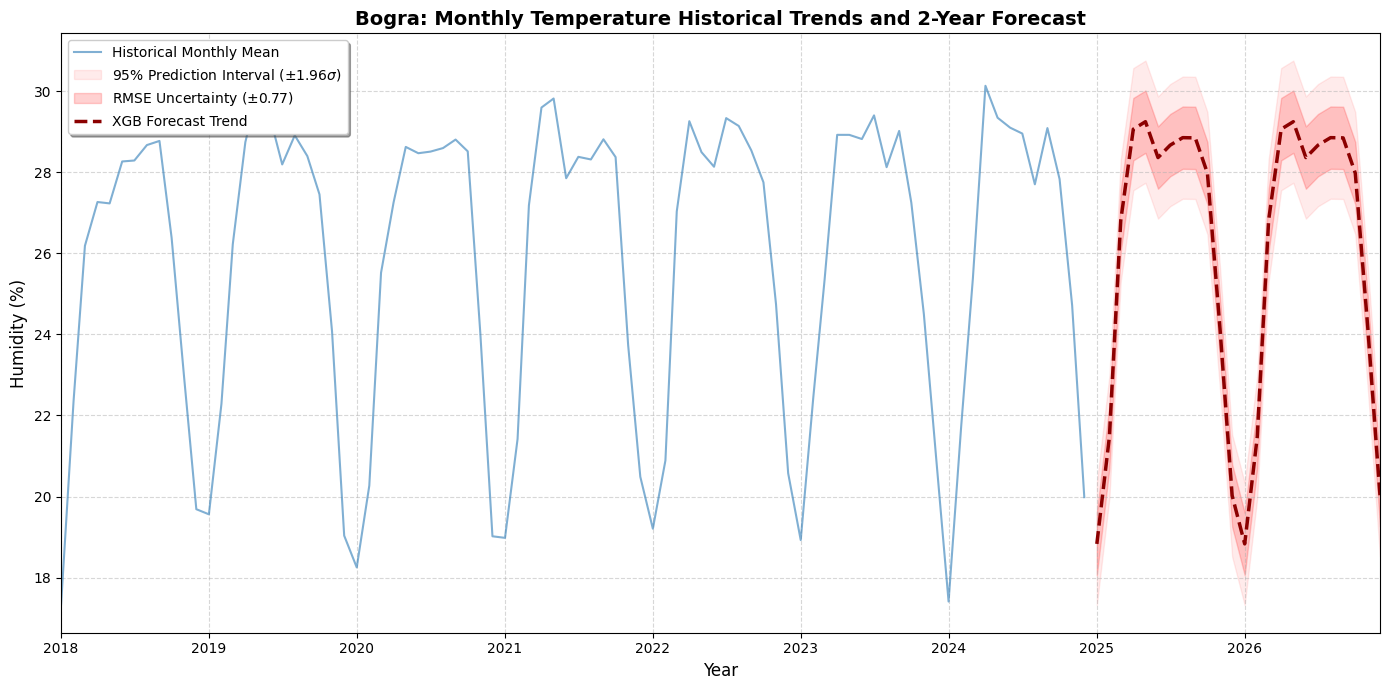

In [33]:
# 5. Predict 2 Years Future with Empirical Validation
mean_preds = lgb_model.predict(future_df[FEATURES])

# 1. Define the Uncertainty Bounds (Based on your LGB RMSE)
best_model_rmse = 0.7689
upper_95 = mean_preds + (1.96 * best_model_rmse)
lower_95 = mean_preds - (1.96 * best_model_rmse)
upper_68 = mean_preds + best_model_rmse
lower_68 = mean_preds - best_model_rmse

# 2. Setup the Plot
plt.figure(figsize=(14, 7))

# 3. Plot Historical Data (The Context)
# Ensure df_features['date'] is in datetime format
plt.plot(df_features['date'], y, label='Historical Monthly Mean', 
         color='#2c7bb6', alpha=0.6, linewidth=1.5)

# 4. Plot the 95% Confidence Interval (The Outer Cloud)
plt.fill_between(future_dates, lower_95, upper_95, 
                 color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')

# 5. Plot the 68% Confidence Interval (The RMSE Cloud)
plt.fill_between(future_dates, lower_68, upper_68, 
                 color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${best_model_rmse:.2f})')

# 6. Plot the Future Prediction Mean (The Trend)
plt.plot(future_dates, mean_preds, label='XGB Forecast Trend', 
         linestyle='--', color='darkred', lw=2.5)

# 7. Journal Formatting & Aesthetics
plt.title('Bogra: Monthly Temperature Historical Trends and 2-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Humidity (%)', fontsize=12)

# Set the x-axis to start slightly before the forecast for better perspective
# Adjust '2018-01-01' to whatever date makes your historical trend visible
plt.xlim(pd.Timestamp('2018-01-01'), future_dates.max()) 

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

In [34]:
df_predictions_temp = pd.DataFrame({
    'date': future_dates,
    'predicted_temp': predictions_temp
})

df_predictions_temp

,date,predicted_temp
0,2025-01-01,18.831604
1,2025-02-01,21.471702
2,2025-03-01,26.805517
3,2025-04-01,29.059471
4,2025-05-01,29.244490
5,2025-06-01,28.359050
6,2025-07-01,28.665257
7,2025-08-01,28.850725
8,2025-09-01,28.845270
9,2025-10-01,27.974303


# Solar radiation

In [35]:
import pandas as pd

In [36]:
df_district = pd.read_csv(f'../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv')

df_district = df_district.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'solar_radiation']
df_district = df_district[desired_colmn]

df_district = df_district.dropna()

df_district.head()

,day,month,year,solar_radiation
12054,1,1,2013,190.3
12055,2,1,2013,182.8
12056,3,1,2013,52.9
12057,4,1,2013,176.6
12058,5,1,2013,192.0


Date range: 2014-01-01 to 2024-12-31


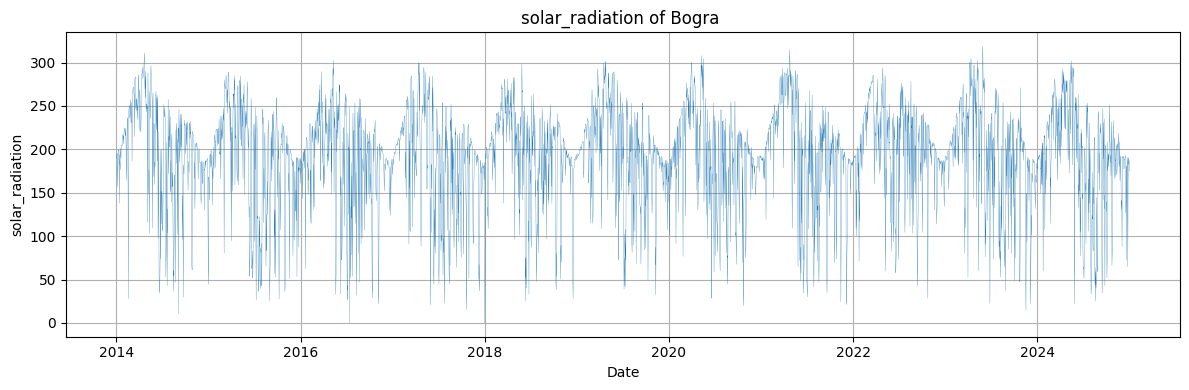

In [37]:
import matplotlib.pyplot as plt

if 'date' not in df_district.columns:
    df_district['date'] = pd.to_datetime(df_district[['year', 'month', 'day']])

# # show date range
# min_date = df_district['date'].min()
# max_date = df_district['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")

# 2010-2024 dile 83% r2 lightgbm
# 2014- 2024 dile 82% R2
# 2018-2024 dile 52% R2 xgboost

# filter data for custom date range: 2020 to 2024
df_district = df_district[
    (df_district['date'] >= '2014-01-01') & (df_district['date'] <= '2024-12-31')
]
custom_range_df = df_district.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()
print(f"Date range: {min_date.date()} to {max_date.date()}")

# plot daily temperature time series
plt.figure(figsize=(12, 4))
plt.plot(df_district['date'], df_district['solar_radiation'], linewidth=0.2)
plt.xlabel('Date')
plt.ylabel('solar_radiation')
plt.title('solar_radiation of Bogra ')
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_hum = df.set_index('date')['solar_radiation'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.dropna()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_hum.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['solar_radiation']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


## RF

In [40]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Humidity Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Humidity Prediction (Test) ===
R²          : 0.6286
RMSE        : 21.442 °C
MSE         : 459.7528
Accuracy (± tolerance):
  ±0.5 °C :  0.00%
  ±1.0 °C :  0.00%
  ±2.0 °C :  3.70%
  ±3.0 °C : 11.11%

=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.6067  (±0.1113)
Scores  : [0.4896 0.5945 0.787  0.4968 0.6657]

=== Feature Importances (Top 10) ===
 feature  importance
   sin_1    0.811020
   cos_1    0.070972
   sin_2    0.051456
year_val    0.031415
   cos_3    0.026604
   cos_2    0.004355
   sin_3    0.004178


## XGB

In [41]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.7399
xgboost_MSE  : 322.0497
xgboost_RMSE : 17.9457
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  3.70%
  ±1.0°C :  3.70%
  ±2.0°C :  7.41%
  ±3.0°C : 11.11%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.4769  |  Std : 0.1938

==== Top Feature Importances ====
 feature  importance
   sin_1    0.315191
   cos_2    0.199362
   sin_2    0.148158
   cos_1    0.117099
   sin_3    0.107968
   cos_3    0.070995
year_val    0.041228


## light gbm

In [42]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) ====
LGB_R^2  : 0.7157
LGB_MSE  : 351.9426
LGB_RMSE : 18.7601
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  3.70%
  ±1.0°C :  3.70%
  ±2.0°C :  7.41%
  ±3.0°C :  7.41%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.6252  |  Std : 0.1296

==== Top Feature Importances ====
 feature   importance
   sin_1 1.722435e+06
year_val 5.365407e+05
   cos_1 3.916133e+05
   cos_2 3.912709e+05
   sin_2 3.322792e+05
   sin_3 2.932523e+05
   cos_3 2.030193e+05


## cat

In [43]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.7111
CatBoost_MSE  : 357.5984
CatBoost_RMSE : 18.9103
Accuracy (|error| ≤ tolerance):
  ±0.5°C :  0.00%
  ±1.0°C :  0.00%
  ±2.0°C :  3.70%
  ±3.0°C : 18.52%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.6134  |  Std : 0.1349

==== Top Feature Importances ====
 feature  importance
   sin_1   50.137935
   sin_2   11.253113
year_val   10.299380
   cos_1    8.334644
   sin_3    7.208371
   cos_2    6.791215
   cos_3    5.975341


## comparision solar radiation

In [44]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2    CV R2        MSE      RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.628626 0.606740 459.752767 21.441846        0.000000        0.000000        3.703704       11.111111
      XGBoost 0.739858 0.476884 322.049716 17.945744        3.703704        3.703704        7.407407       11.111111
     LightGBM 0.715712 0.625216 351.942614 18.760134        3.703704        3.703704        7.407407        7.407407
     CatBoost 0.711143 0.613445 357.598370 18.910272        0.000000        0.000000        3.703704       18.518519


In [45]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
2       LightGBM  0.715712  0.625216  0.090496         0.842224        Robust
3       CatBoost  0.711143  0.613445  0.097698         0.697554        Robust
1        XGBoost  0.739858  0.476884  0.262975         0.550000  Overfit Risk
0  Random Forest  0.628626  0.606740  0.021886         0.418861        Robust


## predicting with best model for 2 yrs solar rad

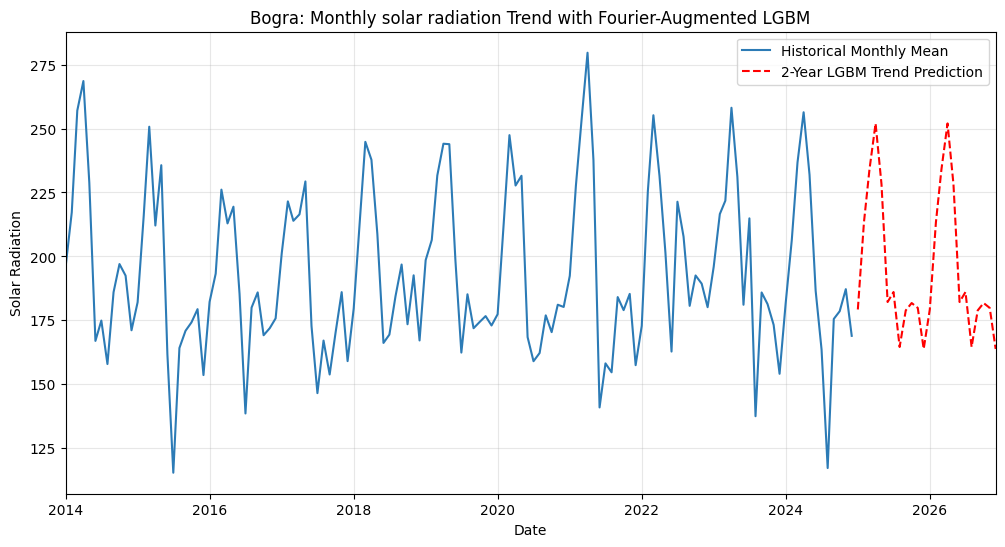

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

# 1. Prepare Monthly Data
df = df_district.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly_rad = df.set_index('date')['solar_radiation'].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly_rad.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['solar_radiation']

# 4. Train Random Forest [cite: 145, 146]
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_solar = lgb_model.predict(future_df[FEATURES])

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_solar, label='2-Year LGBM Trend Prediction', linestyle='--', color='red')
plt.title('Bogra: Monthly solar radiation Trend with Fourier-Augmented LGBM')
plt.xlabel('Date')
plt.ylabel('Solar Radiation')
plt.legend()
plt.grid(True, alpha=0.3)
# Set the start date to Jan 1st, 2023
plt.xlim(pd.Timestamp('2014-01-01'), future_dates.max())
plt.show()

<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:25: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_26752\2982494343.py:21: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')
C:\Users\User\AppData\Local\Temp\ipykernel_26752\2982494343.py:25: SyntaxWarning: "\p" is 

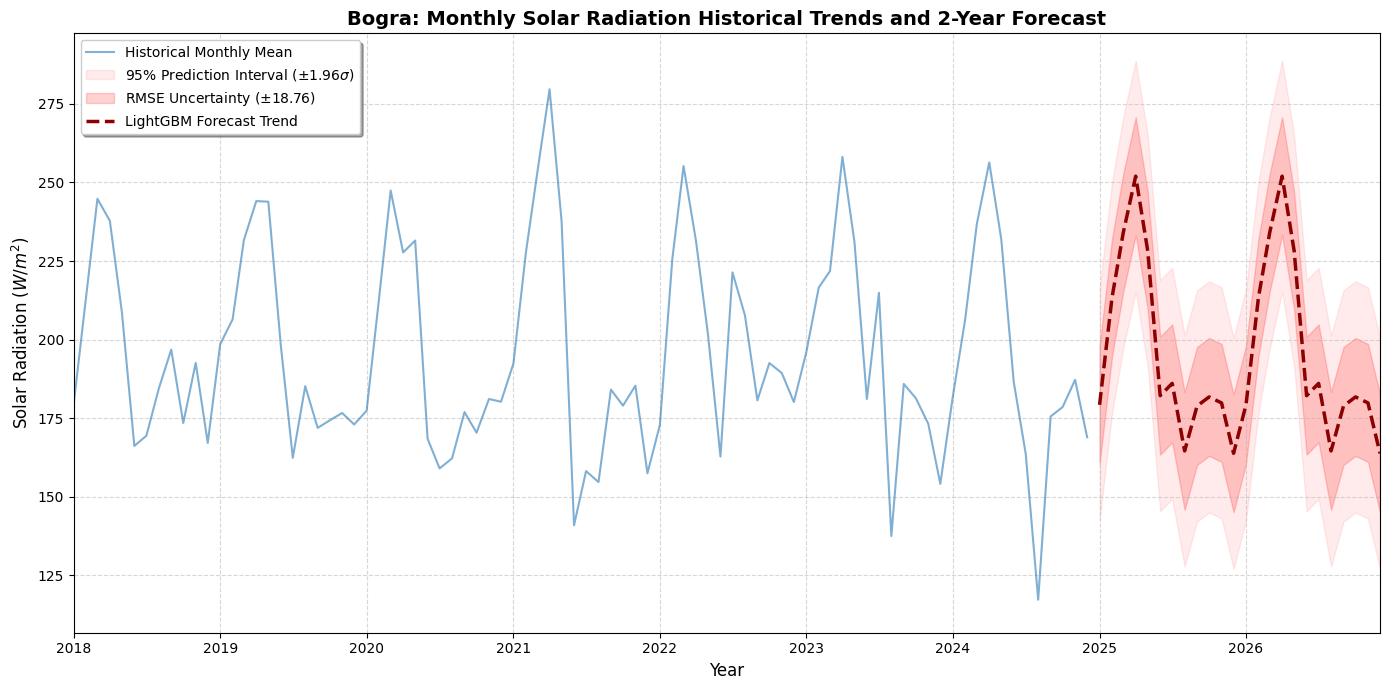

In [52]:
import matplotlib.pyplot as plt
import pandas as pd

mean_preds = lgb_model.predict(future_df[FEATURES])
# 1. Define the Uncertainty Bounds (Based on your LightGBM RMSE)
best_model_rmse = 18.7601
upper_95 = mean_preds + (1.96 * best_model_rmse)
lower_95 = mean_preds - (1.96 * best_model_rmse)
upper_68 = mean_preds + best_model_rmse
lower_68 = mean_preds - best_model_rmse
# 2. Setup the Plot
plt.figure(figsize=(14, 7))

# 3. Plot Historical Data (The Context)
# Ensure df_features['date'] is in datetime format
plt.plot(df_features['date'], y, label='Historical Monthly Mean', 
         color='#2c7bb6', alpha=0.6, linewidth=1.5)

# 4. Plot the 95% Confidence Interval (The Outer Cloud)
plt.fill_between(future_dates, lower_95, upper_95, 
                 color='red', alpha=0.08, label='95% Prediction Interval ($\pm 1.96 \sigma$)')

# 5. Plot the 68% Confidence Interval (The RMSE Cloud)
plt.fill_between(future_dates, lower_68, upper_68, 
                 color='red', alpha=0.18, label=f'RMSE Uncertainty ($\pm${lgb_rmse_f:.2f})')

# 6. Plot the Future Prediction Mean (The Trend)
plt.plot(future_dates, mean_preds, label='LightGBM Forecast Trend', 
         linestyle='--', color='darkred', lw=2.5)

# 7. Journal Formatting & Aesthetics
plt.title('Bogra: Monthly Solar Radiation Historical Trends and 2-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Solar Radiation ($W/m^2$)', fontsize=12)

# Set the x-axis to start slightly before the forecast for better perspective
# Adjust '2018-01-01' to whatever date makes your historical trend visible
plt.xlim(pd.Timestamp('2018-01-01'), future_dates.max()) 

plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

In [53]:
df_predictions_solar = pd.DataFrame({
    'date' : future_dates,
    'predicted_solar' : predictions_solar
})

df_predictions_solar

,date,predicted_solar
0,2025-01-01,179.242468
1,2025-02-01,213.333469
2,2025-03-01,233.999762
3,2025-04-01,251.995622
4,2025-05-01,228.237191
5,2025-06-01,182.155822
6,2025-07-01,186.071252
7,2025-08-01,164.576053
8,2025-09-01,178.868525
9,2025-10-01,181.761262


# Heat Index 

  Calculating heat index with 1980-2024 raw data

In [54]:
import pandas as pd

df_district_2024 = pd.read_csv(f"../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_HI_2024_interpolated = pd.DataFrame()
df_HI_2024_interpolated['date'] = df_monthly_temp['date']
df_HI_2024_interpolated['temperature'] = df_monthly_temp['temperature(degree C)']
df_HI_2024_interpolated['humidity'] = df_monthly_hum['humidity']


# Heat Index Function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    if 0.0 <= h <= 1.0:
        h = h * 100.0

    t_f = t_c * 9.0/5.0 + 32.0

    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    hi_c = (hi - 32.0) * 5.0/9.0
    return hi_c


# Calculate Heat Index
df_HI_2024_interpolated['heat_index_C'] = df_HI_2024_interpolated.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)


df_HI_2024_interpolated


,date,temperature,humidity,heat_index_C
0,1980-01-01,20.403226,69.835484,20.322586
1,1980-02-01,22.341379,66.837931,22.376285
2,1980-03-01,25.625806,74.432258,26.187452
3,1980-04-01,29.070000,74.963333,33.860438
4,1980-05-01,27.946667,81.160000,32.142422
...,...,...,...,...
535,2024-08-01,27.700000,90.212903,32.843620
536,2024-09-01,29.086667,84.653333,36.057320
537,2024-10-01,27.829032,84.835484,32.393003
538,2024-11-01,24.716667,76.196667,25.233469


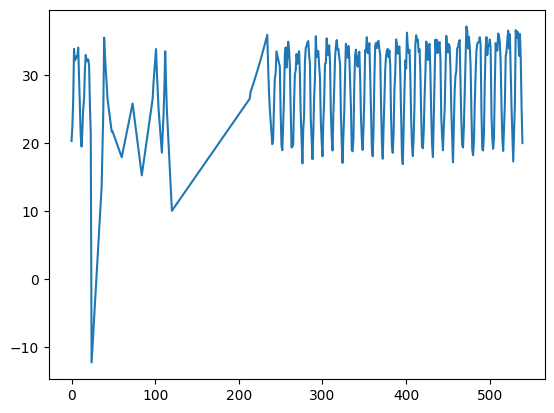

In [55]:
import matplotlib.pyplot as plt

plt.plot(df_HI_2024_interpolated['heat_index_C'])

In [56]:
import pandas as pd

df_district_2024 = pd.read_csv(f"../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_HI_2024 = pd.DataFrame()
df_HI_2024['date'] = df_monthly_temp['date']
df_HI_2024['temperature'] = df_monthly_temp['temperature(degree C)']
df_HI_2024['humidity'] = df_monthly_hum['humidity']


# Heat Index Function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    if 0.0 <= h <= 1.0:
        h = h * 100.0

    t_f = t_c * 9.0/5.0 + 32.0

    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    hi_c = (hi - 32.0) * 5.0/9.0
    return hi_c


# Calculate Heat Index
df_HI_2024['heat_index_C'] = df_HI_2024.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)


df_HI_2024


,date,temperature,humidity,heat_index_C
0,1980-01-01,20.9,75.7,21.022167
1,1980-01-02,22.4,65.0,22.392778
2,1980-01-03,20.4,75.2,20.459111
3,1980-01-04,20.7,70.4,20.663778
4,1980-01-05,20.8,77.1,20.948722
...,...,...,...,...
16432,2024-12-27,19.6,73.2,19.526889
16433,2024-12-28,19.1,76.8,19.070889
16434,2024-12-29,19.2,78.6,19.227889
16435,2024-12-30,19.8,76.6,19.835667


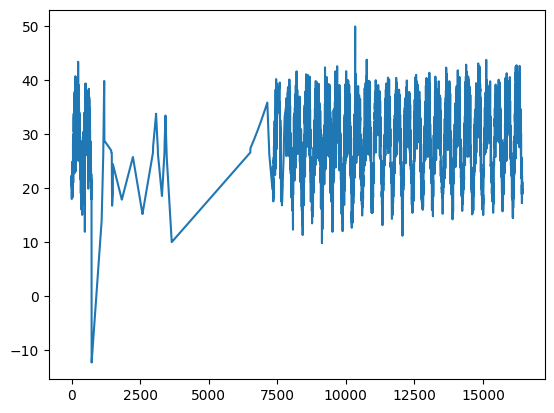

In [57]:
import matplotlib.pyplot as plt

plt.plot(df_HI_2024['heat_index_C'])
# plt.xlim(pd.Timestamp('2014-01-01'))

Calculating heat index with 2025 raw data

In [58]:
# import pandas as pd

# df_district_2025 = pd.read_csv("../2025-dataset/Bogra_historical_weather_2025.csv")

# df = df_district_2025.copy()
# df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().reset_index()
# df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

# df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().reset_index()
# df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

# df_HI_2025 = pd.DataFrame()
# df_HI_2025['date'] = df_monthly_temp['date']
# df_HI_2025['temperature'] = df_monthly_temp['temperature(degree C)']
# df_HI_2025['humidity'] = df_monthly_hum['humidity']


# # Heat Index Function
# def calculate_heat_index(temperature_c, humidity):

#     t_c = float(temperature_c)
#     h = float(humidity)

#     if 0.0 <= h <= 1.0:
#         h = h * 100.0

#     t_f = t_c * 9.0/5.0 + 32.0

#     hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

#     if hi >= 80.0:
#         T = t_f
#         R = h
#         hi = (-42.379 + 2.04901523*T + 10.14333127*R
#               - 0.22475541*T*R - 6.83783e-3*T**2
#               - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
#               + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

#     hi_c = (hi - 32.0) * 5.0/9.0
#     return hi_c


# # Calculate Heat Index
# df_HI_2025['heat_index_C'] = df_HI_2025.apply(
#     lambda r: calculate_heat_index(r['temperature'], r['humidity']),
#     axis=1
# )


# print(df_HI_2025)


In [59]:
import pandas as pd

df_district_2025 = pd.read_csv(f"../../../2025-dataset/{district}_historical_weather_2025.csv")

df = df_district_2025.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# Removed .resample('MS').mean() to keep daily granularity
df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.dropna()

# Removed .resample('MS').mean() to keep daily granularity
df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.dropna()

df_HI_2025 = pd.DataFrame()
df_HI_2025['date'] = df_monthly_temp['date']
df_HI_2025['temperature'] = df_monthly_temp['temperature(degree C)']
df_HI_2025['humidity'] = df_monthly_hum['humidity']


# Heat Index Function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    if 0.0 <= h <= 1.0:
        h = h * 100.0

    t_f = t_c * 9.0/5.0 + 32.0

    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    hi_c = (hi - 32.0) * 5.0/9.0
    return hi_c


# Calculate Heat Index
df_HI_2025['heat_index_C'] = df_HI_2025.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)


print(df_HI_2025)

          date  temperature  humidity  heat_index_C
0   2025-01-01         18.0      86.0     18.101111
1   2025-01-02         17.1      88.5     17.176389
2   2025-01-03         16.7      90.5     16.788611
3   2025-01-04         17.8      91.0     18.011667
4   2025-01-05         19.6      85.6     19.850667
..         ...          ...       ...           ...
319 2025-11-16         23.2      72.6     23.471222
320 2025-11-17         23.7      77.0     24.136111
321 2025-11-18         24.2      73.3     24.589500
322 2025-11-19         23.0      70.3     23.191167
323 2025-11-20         22.7      67.9     22.798500

[324 rows x 4 columns]


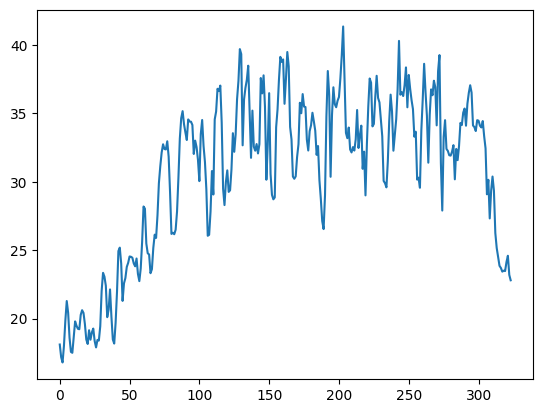

In [60]:
import matplotlib.pyplot as plt
plt.plot(df_HI_2025['heat_index_C'])

 Calculating heat index using predicted temperature and humidity

In [61]:
df_HI = pd.DataFrame()

# Add predicted temperature and humidity
df_HI['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_HI['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values


# Column names
temp_col = 'predicted_temp'
hum_col = 'predicted_humidity'


# Heat Index calculation function
def calculate_heat_index(temperature_c, humidity):

    t_c = float(temperature_c)
    h = float(humidity)

    # If humidity is fraction convert to %
    if 0.0 <= h <= 1.0:
        h = h * 100.0

    # Convert Celsius → Fahrenheit
    t_f = t_c * 9.0/5.0 + 32.0

    # Simple heat index approximation
    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))

    # Full NOAA/NWS formula
    if hi >= 80.0:
        T = t_f
        R = h

        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)

    # Convert Fahrenheit → Celsius
    hi_c = (hi - 32.0) * 5.0/9.0

    return hi_c


# Calculate heat index for predictions
df_HI['predicted_heat_index_C'] = df_HI.apply(
    lambda r: calculate_heat_index(r[temp_col], r[hum_col]),
    axis=1
)

# Inspect results

print(df_HI)

    predicted_temp  predicted_humidity  predicted_heat_index_C
0        18.831604           79.155959               18.837170
1        21.471702           70.462287               21.514277
2        26.805517           69.319944               28.482467
3        29.059471           74.006810               33.639800
4        29.244490           78.541137               35.093644
5        28.359050           85.652517               34.052959
6        28.665257           84.884579               34.815980
7        28.850725           86.555326               35.756287
8        28.845270           86.376893               35.698391
9        27.974303           84.482786               32.739848
10       24.147839           78.422569               24.665879
11       20.023489           78.541556               20.132200
12       18.831604           79.155959               18.837170
13       21.471702           70.462287               21.514277
14       26.805517           69.319944               28

## Plotting real vs predicted heat index

![image.png](attachment:image.png)

error propagation cloud 

In [62]:
# sigma heat index calculation
import numpy as np
temp_rmse = 0.7689
humidity_rmse = 2.5242 
hi_rmse = np.sqrt( (1.1 * temp_rmse)**2 + (0.1 * humidity_rmse)**2 )

C:\Users\User\AppData\Local\Temp\ipykernel_26752\2557569152.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_HI_pred_plot['upper_95'] = df_HI_pred_plot['predicted_heat_index_C'] + (1.96 * hi_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
C:\Users\User\AppData\Local\Temp\ipykernel_26752\2557569152.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_HI_pred_plot['lower_95'] = df_HI_pred_plot['pred

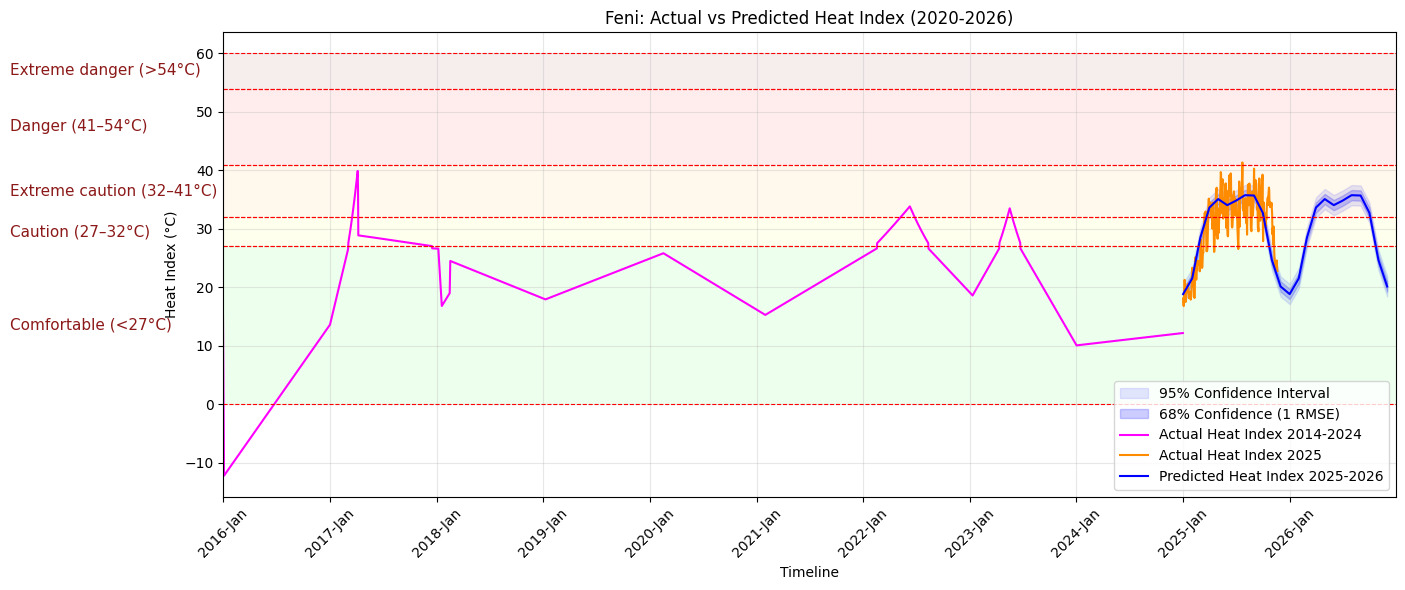

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# --- Ensure datetime index for monthly data ---

# df_HI_2024_interpolated = df_HI_2024_interpolated.copy()
# df_HI_2024_interpolated['date'] = pd.date_range(start='2014-01-01', periods=len(df_HI_2024_interpolated), freq='MS')
# df_HI_2024_interpolated = df_HI_2024_interpolated.set_index('date')

df_HI_2024 = df_HI_2024.copy()
df_HI_2024['date'] = pd.date_range(start='2014-01-01', periods=len(df_HI_2024))
df_HI_2024 = df_HI_2024.set_index('date')

df_HI_2025 = df_HI_2025.copy()
df_HI_2025['date'] = pd.date_range(start='2025-01-01', periods=len(df_HI_2025))
df_HI_2025 = df_HI_2025.set_index('date')

df_HI = df_HI.copy()
df_HI['date'] = pd.date_range(start='2025-01-01', periods=len(df_HI), freq='MS')
df_HI = df_HI.set_index('date')

# --- Filter ranges ---
# df_HI_2024_interpolated_plot = df_HI_2024_interpolated.loc['2014-01-01':'2024-12-31']
df_HI_2024_plot = df_HI_2024.loc['2014-01-01':'2024-12-31']
df_HI_2025_plot = df_HI_2025.loc['2025-01-01':'2025-12-31']
df_HI_pred_plot = df_HI.loc['2025-01-01':'2026-12-31']


# --- Define RMSE for Heat Index ---
# Replace this with your actual Heat Index model RMSE
hi_rmse #########################################################################  

# Calculate bounds for the prediction DataFrame
df_HI_pred_plot['upper_95'] = df_HI_pred_plot['predicted_heat_index_C'] + (1.96 * hi_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
df_HI_pred_plot['lower_95'] = df_HI_pred_plot['predicted_heat_index_C'] - (1.96 * hi_rmse)
df_HI_pred_plot['upper_68'] = df_HI_pred_plot['predicted_heat_index_C'] + hi_rmse
df_HI_pred_plot['lower_68'] = df_HI_pred_plot['predicted_heat_index_C'] - hi_rmse

# --- Plot the Confidence Cloud ---

# 95% Confidence Interval (Lighter Blue)
plt.fill_between(df_HI_pred_plot.index, 
                 df_HI_pred_plot['lower_95'], 
                 df_HI_pred_plot['upper_95'], 
                 color='blue', alpha=0.1, label='95% Confidence Interval')

# 68% Confidence Interval (Slightly Darker Blue)
plt.fill_between(df_HI_pred_plot.index, 
                 df_HI_pred_plot['lower_68'], 
                 df_HI_pred_plot['upper_68'], 
                 color='blue', alpha=0.2, label='68% Confidence (1 RMSE)')




# --- Plot actual vs predicted ---

plt.plot(df_HI_2024_plot.index, df_HI_2024_plot['heat_index_C'], 
         label='Actual Heat Index 2014-2024', color='magenta')

plt.plot(df_HI_2025_plot.index, df_HI_2025_plot['heat_index_C'], 
         label='Actual Heat Index 2025', color='darkorange')

plt.plot(df_HI_pred_plot.index, df_HI_pred_plot['predicted_heat_index_C'], 
         label='Predicted Heat Index 2025-2026', color='blue')
# plt.plot(df_HI_2024_interpolated_plot.index, df_HI_2024_interpolated_plot['heat_index_C'],
#          label='Actual monthly interpolated Heat Index 2014-2024', color='black')

# --- Labels and title ---
plt.xlabel('Timeline')
plt.ylabel('Heat Index (°C)')
plt.title(f'{district}: Actual vs Predicted Heat Index (2020-2026)')

# --- Heat index bands ---
bands = [
    (0, 27, "Comfortable (<27°C)", (0, 1, 0, 0.07)),        # Green
    (27, 32, "Caution (27–32°C)", (1, 1, 0, 0.07)),          # Yellow
    (32, 41, "Extreme caution (32–41°C)", (1, 0.65, 0, 0.07)), # Orange
    (41, 54, "Danger (41–54°C)", (1, 0, 0, 0.07)),           # Red
    (54, 60, "Extreme danger (>54°C)", (0.5, 0, 0, 0.07))    # Dark Red
]

ax = plt.gca()
for low, high, label, color in bands:
    ax.axhspan(low, high, facecolor=color, edgecolor=None)
    plt.axhline(y=low, color='red', linestyle='--', linewidth=0.8)
    plt.axhline(y=high, color='red', linestyle='--', linewidth=0.8)
    plt.text(
        x=df_HI_2024_plot.index.min(),
        y=(low + high)/2,
        s=label,
        fontsize=11,
        color="maroon",
        va="center",
        ha="left",
        alpha=0.9
    )

# --- X-axis formatting ---
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'))

plt.legend()
plt.tight_layout()
plt.show()

# Wet Bulb

Calculating wet bulb with 1980-2024 raw data

In [64]:
import pandas as pd
import numpy as np

df_district_2024 = pd.read_csv(f"../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_WB_2024 = pd.DataFrame()
df_WB_2024['date'] = df_monthly_temp['date']
df_WB_2024['temperature'] = df_monthly_temp['temperature(degree C)']
df_WB_2024['humidity'] = df_monthly_hum['humidity']


# Wet Bulb Function (Stull's Equation)
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WB_2024['wet_bulb_C'] = df_WB_2024.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

df_WB_2024

,date,temperature,humidity,wet_bulb_C
0,1980-01-01,20.9,75.7,17.847277
1,1980-01-02,22.4,65.0,17.846282
2,1980-01-03,20.4,75.2,17.310168
3,1980-01-04,20.7,70.4,16.983339
4,1980-01-05,20.8,77.1,17.930128
...,...,...,...,...
16432,2024-12-27,19.6,73.2,16.305008
16433,2024-12-28,19.1,76.8,16.274765
16434,2024-12-29,19.2,78.6,16.590112
16435,2024-12-30,19.8,76.6,16.915901


 Calculating wet bulb with 2025 raw data

In [65]:
import pandas as pd
import numpy as np

df_district_2025 = pd.read_csv(f"../../../2025-dataset/{district}_historical_weather_2025.csv")

df = df_district_2025.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.dropna()

df_WB_2025 = pd.DataFrame()
df_WB_2025['date'] = df_monthly_temp['date']
df_WB_2025['temperature'] = df_monthly_temp['temperature(degree C)']
df_WB_2025['humidity'] = df_monthly_hum['humidity']


# Wet Bulb Function (Stull's Equation)
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WB_2025['wet_bulb_C'] = df_WB_2025.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

print(df_WB_2025)

          date  temperature  humidity  wet_bulb_C
0   2025-01-01         18.0      86.0   16.323185
1   2025-01-02         17.1      88.5   15.737645
2   2025-01-03         16.7      90.5   15.577369
3   2025-01-04         17.8      91.0   16.721563
4   2025-01-05         19.6      85.6   17.834618
..         ...          ...       ...         ...
319 2025-11-16         23.2      72.6   19.612286
320 2025-11-17         23.7      77.0   20.677986
321 2025-11-18         24.2      73.3   20.647869
322 2025-11-19         23.0      70.3   19.115256
323 2025-11-20         22.7      67.9   18.513246

[324 rows x 4 columns]


Calculating wet bulb using predicted temperature and humidity

In [66]:
df_WB = pd.DataFrame()

# Add predicted temperature and humidity
df_WB['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_WB['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values


# Column names
temp_col = 'predicted_temp'
hum_col = 'predicted_humidity'


def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate wet bulb temperature for predictions
df_WB['predicted_wet_bulb_C'] = df_WB.apply(
    lambda r: calculate_wet_bulb(r[temp_col], r[hum_col]),
    axis=1
)

# Inspect results

print(df_WB)

    predicted_temp  predicted_humidity  predicted_wet_bulb_C
0        18.831604           79.155959             16.305232
1        21.471702           70.462287             17.711273
2        26.805517           69.319944             22.520095
3        29.059471           74.006810             25.329512
4        29.244490           78.541137             26.186728
5        28.359050           85.652517             26.377034
6        28.665257           84.884579             26.563689
7        28.850725           86.555326             26.987743
8        28.845270           86.376893             26.956435
9        27.974303           84.482786             25.833810
10       24.147839           78.422569             21.297614
11       20.023489           78.541556             17.370335
12       18.831604           79.155959             16.305232
13       21.471702           70.462287             17.711273
14       26.805517           69.319944             22.520095
15       29.059471      

https://journals.ametsoc.org/view/journals/apme/50/11/jamc-d-11-0143.1.xml

![image.png](attachment:image.png)

![image-2.png](attachment:image-2.png)

In [67]:
import numpy as np

wb_rmse = np.sqrt( (0.6 * temp_rmse)**2 + (0.2 * humidity_rmse)**2 )

## Plotting real vs predicted wet bulb

C:\Users\User\AppData\Local\Temp\ipykernel_26752\2186352038.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WB_pred_plot['upper_95'] = df_WB_pred_plot['predicted_wet_bulb_C'] + (1.96 * wb_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
C:\Users\User\AppData\Local\Temp\ipykernel_26752\2186352038.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WB_pred_plot['lower_95'] = df_WB_pred_plot['predic

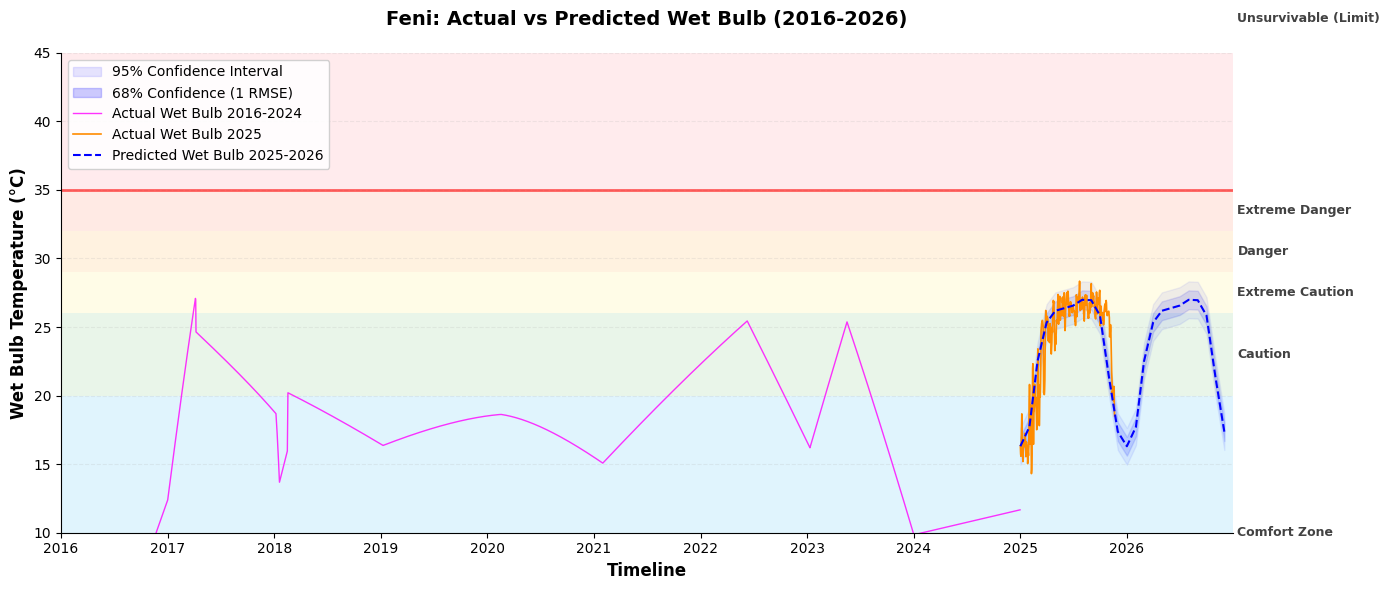

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# --- Ensure datetime index for monthly data ---
df_WB_2024 = df_WB_2024.copy()
df_WB_2024['date'] = pd.date_range(start='2014-01-01', periods=len(df_WB_2024)) ########################
df_WB_2024 = df_WB_2024.set_index('date')

df_WB_2025 = df_WB_2025.copy()
df_WB_2025['date'] = pd.date_range(start='2025-01-01', periods=len(df_WB_2025))
df_WB_2025 = df_WB_2025.set_index('date')

df_WB = df_WB.copy()
df_WB['date'] = pd.date_range(start='2025-01-01', periods=len(df_WB), freq='MS')
df_WB = df_WB.set_index('date')

# --- Filter ranges ---
df_WB_2024_plot = df_WB_2024.loc['2014-01-01':'2024-12-31']
df_WB_2025_plot = df_WB_2025.loc['2025-01-01':'2025-12-31']
df_WB_pred_plot = df_WB.loc['2025-01-01':'2026-12-31']


# --- Define RMSE for wet bulb ---
# Replace this with your actual Wet Bulb model RMSE
wb_rmse #########################################################################  

# Calculate bounds for the prediction DataFrame
df_WB_pred_plot['upper_95'] = df_WB_pred_plot['predicted_wet_bulb_C'] + (1.96 * wb_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
df_WB_pred_plot['lower_95'] = df_WB_pred_plot['predicted_wet_bulb_C'] - (1.96 * wb_rmse)
df_WB_pred_plot['upper_68'] = df_WB_pred_plot['predicted_wet_bulb_C'] + wb_rmse
df_WB_pred_plot['lower_68'] = df_WB_pred_plot['predicted_wet_bulb_C'] - wb_rmse

# --- Plot the Confidence Cloud ---

# 95% Confidence Interval (Lighter Blue)
plt.fill_between(df_WB_pred_plot.index, 
                 df_WB_pred_plot['lower_95'], 
                 df_WB_pred_plot['upper_95'], 
                 color='blue', alpha=0.1, label='95% Confidence Interval')

# 68% Confidence Interval (Slightly Darker Blue)
plt.fill_between(df_WB_pred_plot.index, 
                 df_WB_pred_plot['lower_68'], 
                 df_WB_pred_plot['upper_68'], 
                 color='blue', alpha=0.2, label='68% Confidence (1 RMSE)')

# --- Plot actual vs predicted ---
plt.plot(df_WB_2024_plot.index, df_WB_2024_plot['wet_bulb_C'],
         label='Actual Wet Bulb 2016-2024', color='magenta', linewidth=1, alpha=0.8)

plt.plot(df_WB_2025_plot.index, df_WB_2025_plot['wet_bulb_C'],
         label='Actual Wet Bulb 2025', color='darkorange', linewidth=1.2)

plt.plot(df_WB_pred_plot.index, df_WB_pred_plot['predicted_wet_bulb_C'],
         label='Predicted Wet Bulb 2025-2026', color='blue', linestyle='--', linewidth=1.5)

# --- Labels and title ---
plt.xlabel('Timeline', fontsize=12, fontweight='bold')
plt.ylabel('Wet Bulb Temperature (°C)', fontsize=12, fontweight='bold')
plt.title(f'{district}: Actual vs Predicted Wet Bulb (2016-2026)', 
          fontsize=14, pad=20, fontweight='bold')

# --- Comfort & Danger Boundary Conditions ---
ax = plt.gca()

# Defining the zones: (Bottom_Temp, Top_Temp, Color, Label)
zones = [
    (0, 20, '#b3e5fc', 'Comfort Zone'),           # Light Blue
    (20, 26, '#c8e6c9', 'Caution'),                # Light Green
    (26, 29, '#fff9c4', 'Extreme Caution'),        # Light Yellow
    (29, 32, '#ffe0b2', 'Danger'),                 # Light Orange
    (32, 35, '#ffccbc', 'Extreme Danger'),         # Light Red/Coral
    (35, 60, '#ffcdd2', 'Unsurvivable (Limit)')    # Deep Red
]

for bottom, top, color, label in zones:
    ax.axhspan(bottom, top, facecolor=color, alpha=0.4, edgecolor=None)
    # Adding subtle text labels on the right edge for a clean journal look
    plt.text(pd.Timestamp('2027-01-15'), (bottom + top) / 2, label, 
             fontsize=9, color='#424242', va='center', fontweight='bold')

# Highlight the critical 35°C threshold
plt.axhline(y=35, color='red', linestyle='-', linewidth=2, alpha=0.6)

# --- X-axis formatting ---
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0) # Flat labels look cleaner in journals if space permits

plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'))
plt.ylim(10, 45) # Focused range for Wet Bulb visibility

# Clean up legend and spine
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Wet Bulb Globe Temperature 

Calculating wet bulb globe with 1980-2024 raw data

In [69]:
import pandas as pd
import numpy as np

df_district_2024 = pd.read_csv(f"../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

df_monthly_hum = df.set_index('date')['humidity'].interpolate(method='linear').reset_index()
df_monthly_hum = df_monthly_hum.interpolate(method='linear').dropna()

df_monthly_temp = df.set_index('date')['temperature(degree C)'].interpolate(method='linear').reset_index()
df_monthly_temp = df_monthly_temp.interpolate(method='linear').dropna()

df_monthly_solar = df.set_index('date')['solar_radiation'].interpolate(method='linear').reset_index()
df_monthly_solar = df_monthly_solar.interpolate(method='linear').dropna()

df_WB_2024 = pd.DataFrame()
df_WB_2024['date'] = df_monthly_temp['date']
df_WB_2024['temperature'] = df_monthly_temp['temperature(degree C)']
df_WB_2024['humidity'] = df_monthly_hum['humidity']
df_WB_2024['solar_radiation'] = df_monthly_solar['solar_radiation']


# Wet Bulb Function (Stull's Equation)
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WB_2024['wet_bulb_C'] = df_WB_2024.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

df_WB_2024['WBGT'] = (
    0.7 * df_WB_2024['wet_bulb_C']
    + 0.2 * (df_WB_2024['temperature'] + 0.0003 * df_WB_2024['solar_radiation'])
    + 0.1 * df_WB_2024['temperature']
)


df_WBG_2024 = df_WB_2024[[
    'date',
    'temperature',
    'humidity',
    'solar_radiation',
    'wet_bulb_C',
    'WBGT'
]]

df_WBG_2024

,date,temperature,humidity,solar_radiation,wet_bulb_C,WBGT
0,1980-01-01,20.9,75.7,NaN,17.847277,NaN
1,1980-01-02,22.4,65.0,NaN,17.846282,NaN
2,1980-01-03,20.4,75.2,NaN,17.310168,NaN
3,1980-01-04,20.7,70.4,NaN,16.983339,NaN
4,1980-01-05,20.8,77.1,NaN,17.930128,NaN
...,...,...,...,...,...,...
16432,2024-12-27,19.6,73.2,190.2,16.305008,17.304917
16433,2024-12-28,19.1,76.8,188.2,16.274765,17.133628
16434,2024-12-29,19.2,78.6,182.6,16.590112,17.384035
16435,2024-12-30,19.8,76.6,187.1,16.915901,17.792357


Calculating wet bulb globe with 2025 raw data

In [70]:
import pandas as pd
import numpy as np


df_2025 = pd.read_csv(f"../../../2025-dataset/{district}_historical_weather_2025.csv")

df_2025['date'] = pd.to_datetime(df_2025[['year', 'month', 'day']])


df_2025 = df_2025.set_index('date')

df_monthly_2025 = df_2025.resample('D')[[ ############### 
    'temperature(degree C)',
    'humidity',
    'solar_radiation'
]].mean()


full_range = pd.date_range(
    start='2025-01-01',
    end='2025-11-01',
    freq='D'
)

df_monthly_2025 = df_monthly_2025.reindex(full_range)


df_monthly_2025 = df_monthly_2025.interpolate(method='linear')


df_monthly_2025 = df_monthly_2025.reset_index()
df_monthly_2025.rename(columns={
    'index': 'date',
    'temperature(degree C)': 'temperature_C'
}, inplace=True)

def calculate_wet_bulb(T, RH):

    RH = np.where(RH <= 1, RH*100, RH)

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw

df_monthly_2025['wet_bulb_C'] = calculate_wet_bulb(
    df_monthly_2025['temperature_C'],
    df_monthly_2025['humidity']
)


df_monthly_2025['WBGT'] = (
    0.7 * df_monthly_2025['wet_bulb_C']
    + 0.2 * (df_monthly_2025['temperature_C'] + 0.0003 * df_monthly_2025['solar_radiation'])
    + 0.1 * df_monthly_2025['temperature_C']
)


df_WBG_2025 = df_monthly_2025[[
    'date',
    'temperature_C',
    'humidity',
    'solar_radiation',
    'wet_bulb_C',
    'WBGT'
]]

df_WBG_2025

,date,temperature_C,humidity,solar_radiation,wet_bulb_C,WBGT
0,2025-01-01,18.0,86.0,182.4,16.323185,16.837174
1,2025-01-02,17.1,88.5,185.5,15.737645,16.157482
2,2025-01-03,16.7,90.5,178.1,15.577369,15.924844
3,2025-01-04,17.8,91.0,159.8,16.721563,17.054682
4,2025-01-05,19.6,85.6,164.0,17.834618,18.374073
...,...,...,...,...,...,...
300,2025-10-28,28.9,80.0,210.6,26.073654,26.934194
301,2025-10-29,28.7,80.9,184.5,26.014185,26.830999
302,2025-10-30,28.5,83.1,179.5,26.143289,26.861072
303,2025-10-31,28.8,81.2,172.4,26.154616,26.958575


In [71]:
df_predictions_solar

,date,predicted_solar
0,2025-01-01,179.242468
1,2025-02-01,213.333469
2,2025-03-01,233.999762
3,2025-04-01,251.995622
4,2025-05-01,228.237191
5,2025-06-01,182.155822
6,2025-07-01,186.071252
7,2025-08-01,164.576053
8,2025-09-01,178.868525
9,2025-10-01,181.761262


## Calculating wet bulb globe with predicted values for next 2 years 

In [72]:
import pandas as pd
import numpy as np

# Create dataframe
df_WBG = pd.DataFrame()

# Add date column (recommended for time series)
df_WBG['date'] = df_predictions_solar['date']

# Add predicted variables
df_WBG['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_WBG['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values
df_WBG['predicted_solar'] = df_predictions_solar['predicted_solar'].values


# Wet Bulb Function
def calculate_wet_bulb(temperature_c, humidity):

    T = float(temperature_c)
    RH = float(humidity)

    # Convert RH if given as fraction
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0

    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )

    return Tw


# Calculate Wet Bulb Temperature
df_WBG['predicted_wet_bulb_C'] = df_WBG.apply(
    lambda r: calculate_wet_bulb(r['predicted_temp'], r['predicted_humidity']),
    axis=1
)


# Calculate WBGT
# WBGT ≈ 0.7 × Tw + 0.2 × (T + 0.025 × SR) + 0.1 × T

df_WBG['predicted_WBGT'] = (
    0.7 * df_WBG['predicted_wet_bulb_C']
    + 0.2 * (df_WBG['predicted_temp'] + 0.025 * df_WBG['predicted_solar'])
    + 0.1 * df_WBG['predicted_temp']
)

# reference for changing 0.0003 to 0.025 https://www.iaeng.org/publication/WCECS2011/WCECS2011_pp591-599.pdf

df_WBG

,date,predicted_temp,predicted_humidity,predicted_solar,predicted_wet_bulb_C,predicted_WBGT
0,2025-01-01,18.831604,79.155959,179.242468,16.305232,17.959356
1,2025-02-01,21.471702,70.462287,213.333469,17.711273,19.906069
2,2025-03-01,26.805517,69.319944,233.999762,22.520095,24.975721
3,2025-04-01,29.059471,74.006810,251.995622,25.329512,27.708478
4,2025-05-01,29.244490,78.541137,228.237191,26.186728,28.245243
5,2025-06-01,28.359050,85.652517,182.155822,26.377034,27.882418
6,2025-07-01,28.665257,84.884579,186.071252,26.563689,28.124516
7,2025-08-01,28.850725,86.555326,164.576053,26.987743,28.369518
8,2025-09-01,28.845270,86.376893,178.868525,26.956435,28.417428
9,2025-10-01,27.974303,84.482786,181.761262,25.833810,27.384764


The WBGT Error Propagation FormulaWBGT typically depends on three main variables: Natural Wet Bulb Temperature ($T_w$), Globe Temperature ($T_g$), and Air Temperature ($T_d$). The standard outdoor formula is:$$WBGT = 0.7T_w + 0.2T_g + 0.1T_d$$To find the propagated error ($\sigma_{WBGT}$), we use the Root-Sum-Square (RSS) of the partial derivatives:

$$\sigma_{WBGT} = \sqrt{\left(\frac{\partial WBGT}{\partial T_w} \cdot \text{RMSE}_{T_w}\right)^2 + \left(\frac{\partial WBGT}{\partial T_g} \cdot \text{RMSE}_{T_g}\right)^2 + \left(\frac{\partial WBGT}{\partial T_d} \cdot \text{RMSE}_{T_d}\right)^2}$$


Because your formula is $WBGT = 0.7(T_w) + 0.2(T + 0.025 \cdot SR) + 0.1(T)$, 

the sensitivity coefficients are the "weights" that determine how much an error in one sensor affects the final result.

<b>1. Solar Radiation Sensitivity ($S_{SR}$)</b>

Coefficient: $0.00006$
In your code, you have 0.2 * (0.0003 * SR). Mathematically, the partial derivative with respect to Solar Radiation is:
$\frac{\partial WBGT}{\partial SR} = 0.2 \times 0.025 = \mathbf{0.005}$

What this means: If your solar radiation prediction is off by 100 $W/m^2$, your WBGT error increases by only 0.006°C. This variable has very low sensitivity in your current model.

<b>2. Humidity Sensitivity ($S_H$)</b>

Coefficient: $\approx 0.11$ to $0.20$

Humidity only enters your formula through the calculate_wet_bulb (Stull) function, which is then multiplied by $0.7$.

- Based on Lanzante (2024) and the Stull regression dynamics, the partial derivative 
$\frac{\partial T_w}{\partial RH}$ typically ranges from $0.15$ to $0.28$ in tropical conditions.
- Multiplying by your $0.7$ weight: $0.7 \times 0.22 \approx \mathbf{0.15}$.
- Use 0.15 as a solid representative value for tropical research.

<b>3. Temperature Sensitivity ($S_T$)</b>

Coefficient: $\approx 0.75$ to $0.85$
Temperature is the most complex because it appears in three places in your code: inside the Wet Bulb function, inside the Globe Temp bracket, and in the final $0.1T$ term.

- From $0.1T$: Sensitivity is $0.1$.
- From $0.2(T + ...)$: Sensitivity is $0.2$.
- From $0.7(T_w)$: The partial derivative $\frac{\partial T_w}{\partial T}$ is usually around $0.7$ to $0.8$ in warm weather. $0.7 \times 0.75 = 0.525$.
- Total Sensitivity: $0.1 + 0.2 + 0.525 = \mathbf{0.825}$.

final equation: 
$$\sigma_{WBGT} = \sqrt{(0.83 \cdot \text{RMSE}_T)^2 + (0.15 \cdot \text{RMSE}_H)^2 + (0.005 \cdot \text{RMSE}_{SR})^2}$$

![image.png](attachment:image.png)

reference: 
- ISO (2017). ISO 7243:2017 - Ergonomics of the thermal environment — Assessment of heat stress using the WBGT (wet bulb globe temperature) index. International Organization for Standardization.

- Yaglou, C. P., & Minard, D. (1957). Control of heat casualties at military training centers. Archives of Industrial Health, 16(4), 302–316.

## Plotting real vs predicted 

$$\sigma_{WBGT} = \sqrt{(0.83 \cdot \text{RMSE}_T)^2 + (0.15 \cdot \text{RMSE}_H)^2 + (0.005 \cdot \text{RMSE}_{SR})^2}$$

In [73]:
import numpy as np

rmse_solar = 18.7601
wbg_rmse = np.sqrt((0.83 * temp_rmse)**2 + (0.15 * humidity_rmse)**2 + (0.005 * rmse_solar)**2)

C:\Users\User\AppData\Local\Temp\ipykernel_26752\1394522954.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WBG_pred_plot['upper_95'] = df_WBG_pred_plot['predicted_wet_bulb_C'] + (1.96 * wbg_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
C:\Users\User\AppData\Local\Temp\ipykernel_26752\1394522954.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_WBG_pred_plot['lower_95'] = df_WBG_pred_plot['p

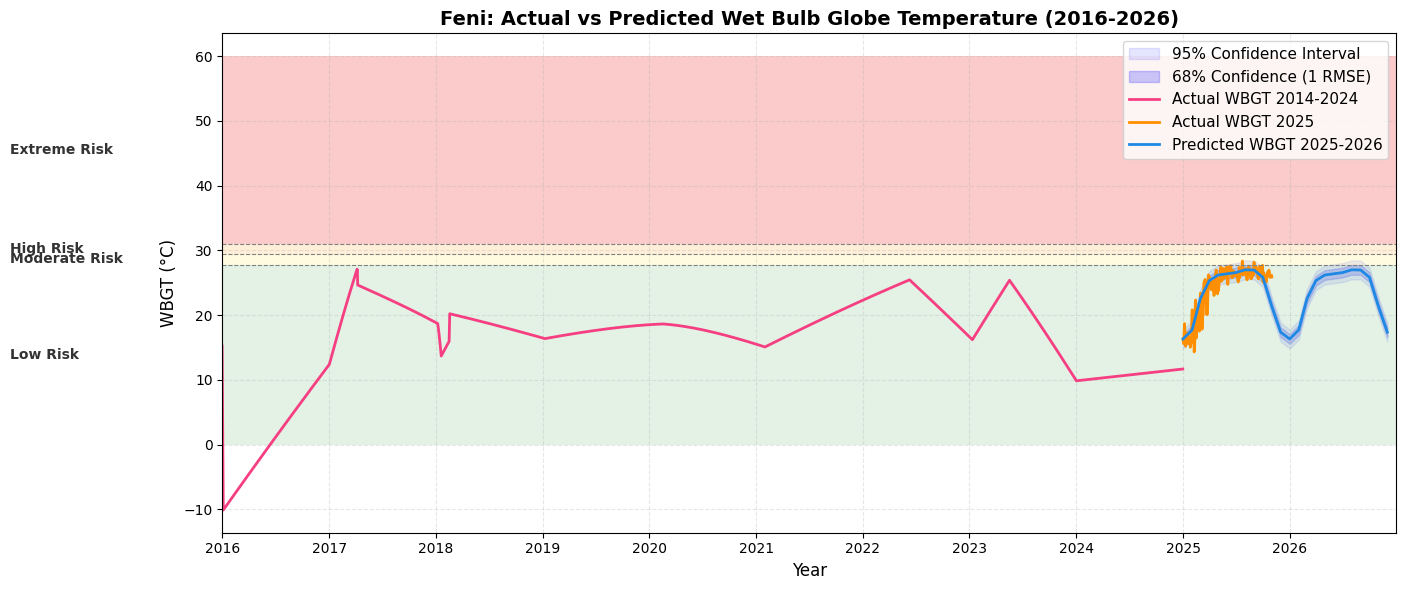

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# --- Ensure datetime index ---
df_WBG_2024 = df_WBG_2024.copy()
df_WBG_2024['date'] = pd.date_range(start='2014-01-01', periods=len(df_WBG_2024))
df_WBG_2024 = df_WBG_2024.set_index('date')

df_WBG_2025 = df_WBG_2025.copy()
df_WBG_2025['date'] = pd.date_range(start='2025-01-01', periods=len(df_WBG_2025))
df_WBG_2025 = df_WBG_2025.set_index('date')

df_WBG = df_WBG.copy()
df_WBG['date'] = pd.date_range(start='2025-01-01', periods=len(df_WBG), freq='MS')
df_WBG = df_WBG.set_index('date')


# --- Filter ranges for plotting ---
df_WBG_2024_plot = df_WBG_2024.loc['2014-01-01':'2024-12-31']
df_WBG_2025_plot = df_WBG_2025.loc['2025-01-01':'2025-12-31']
df_WBG_pred_plot = df_WBG.loc['2025-01-01':'2026-12-31']


# --- Define RMSE for Heat Index ---
# Replace this with your actual Heat Index model RMSE
wbg_rmse #########################################################################  

# Calculate bounds for the prediction DataFrame
df_WBG_pred_plot['upper_95'] = df_WBG_pred_plot['predicted_wet_bulb_C'] + (1.96 * wbg_rmse) # Statistics tells us that in a perfect "Bell Curve" (Normal Distribution), 95% of all values fall within 1.96 standard deviations of the mean.
df_WBG_pred_plot['lower_95'] = df_WBG_pred_plot['predicted_wet_bulb_C'] - (1.96 * wbg_rmse)
df_WBG_pred_plot['upper_68'] = df_WBG_pred_plot['predicted_wet_bulb_C'] + wbg_rmse
df_WBG_pred_plot['lower_68'] = df_WBG_pred_plot['predicted_wet_bulb_C'] - wbg_rmse

# --- Plot the Confidence Cloud ---

# 95% Confidence Interval (Lighter Blue)
plt.fill_between(df_WBG_pred_plot.index, 
                 df_WBG_pred_plot['lower_95'], 
                 df_WBG_pred_plot['upper_95'], 
                 color='blue', alpha=0.1, label='95% Confidence Interval')

# 68% Confidence Interval (Slightly Darker Blue)
plt.fill_between(df_WBG_pred_plot.index, 
                 df_WBG_pred_plot['lower_68'], 
                 df_WBG_pred_plot['upper_68'], 
                 color='blue', alpha=0.2, label='68% Confidence (1 RMSE)')




# --- Plot actual vs predicted WBGT ---
plt.plot(df_WBG_2024_plot.index, df_WBG_2024_plot['wet_bulb_C'],
         label='Actual WBGT 2014-2024', color="#F53F82", linewidth=2)

plt.plot(df_WBG_2025_plot.index, df_WBG_2025_plot['wet_bulb_C'],
         label='Actual WBGT 2025', color='#FF8F00', linewidth=2)

plt.plot(df_WBG_pred_plot.index, df_WBG_pred_plot['predicted_wet_bulb_C'],
         label='Predicted WBGT 2025-2026', color='#1E88E5', linewidth=2)

# --- Risk category bands with labels ---
ax = plt.gca()
bands = [
    (0, 27.8, "Low Risk", "#A5D6A7"),
    (27.8, 29.4, "Moderate Risk", "#FFF59D"),
    (29.4, 31, "High Risk", "#FFCC80"),
    (31, 60, "Extreme Risk", "#EF5350")
]

for start, end, label, color in bands:
    ax.axhspan(start, end, facecolor=color, alpha=0.3)
    # Add text label inside the band
    y_pos = start + (end - start)/2
    ax.text(df_WBG_2024_plot.index[3], y_pos, label,
            fontsize=10, fontweight='bold', color='black', alpha=0.8, va='center')

# --- Threshold lines ---
thresholds = [27.8, 29.4, 31]
for t in thresholds:
    plt.axhline(y=t, color='gray', linestyle='--', linewidth=0.8)

# --- Labels, title, legend ---
plt.xlabel('Year', fontsize=12)
plt.ylabel('WBGT (°C)', fontsize=12)
plt.title(f'{district}: Actual vs Predicted Wet Bulb Globe Temperature (2016-2026)', fontsize=14, fontweight='bold')

plt.legend(frameon=True, fontsize=11)

# --- X-axis formatting ---
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

plt.grid(alpha=0.3, linestyle='--')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2026-12-31'))

plt.tight_layout()
plt.show()

## Calculating Heatstroke Risk

Calculating heatstroke risk using 1980-2024 raw data

In [75]:
import pandas as pd
import numpy as np

# --- Load datasets ---
df_district_2024 = pd.read_csv(f"../../../1980-2024-dataset/{district}_historical_weather_1980_2024.csv")

df = df_district_2024.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# --- Monthly resampling and interpolation ---
df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().interpolate()
df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().interpolate()

# --- Heat Index Calculation ---
df_HI_2024 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_heat_index(temperature_c, humidity):
    t_c = float(temperature_c)
    h = float(humidity)
    if 0.0 <= h <= 1.0:
        h = h * 100.0
    t_f = t_c * 9.0/5.0 + 32.0
    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))
    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)
    return (hi - 32.0) * 5.0/9.0

df_HI_2024['heat_index_C'] = df_HI_2024.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)

# --- Wet Bulb Calculation (Stull) ---
df_WB_2024 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_wet_bulb(T, RH):
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0
    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )
    return Tw

df_WB_2024['wet_bulb_C'] = df_WB_2024.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

# --- Ensure full 1980-2024 monthly range ---
date_range = pd.date_range(start='1980-01-01', end='2024-12-01', freq='MS')

df_HI_2024 = df_HI_2024.set_index('date').reindex(date_range).interpolate().reset_index()
df_HI_2024.rename(columns={'index':'date'}, inplace=True)

df_WB_2024 = df_WB_2024.set_index('date').reindex(date_range).interpolate().reset_index()
df_WB_2024.rename(columns={'index':'date'}, inplace=True)

# --- Merge datasets ---
df_heatstress_2024 = pd.merge(
    df_HI_2024[['date', 'heat_index_C']],
    df_WB_2024[['date', 'wet_bulb_C']],
    on='date'
)

# --- Heatstroke Risk Function ---
def calculate_heatstroke_risk(heat_index_c, wet_bulb_c):
    HI_F = heat_index_c * 9/5 + 32  # Heat Index in Fahrenheit
    beta0 = -18
    beta1 = 0.15
    risk_hi = 1 / (1 + np.exp(-(beta0 + beta1 * HI_F)))

    if wet_bulb_c >= 35:
        wb_factor = 1.0  # unsurvivable
    elif wet_bulb_c >= 30:
        wb_factor = 0.8  # extreme
    elif wet_bulb_c >= 27:
        wb_factor = 0.5  # moderate
    else:
        wb_factor = 0.2  # low

    risk = risk_hi * wb_factor
    return min(risk, 1)

df_heatstress_2024['heatstroke_risk'] = df_heatstress_2024.apply(
    lambda r: calculate_heatstroke_risk(r['heat_index_C'], r['wet_bulb_C']),
    axis=1
)

#df_heatstress_2024['unsurvivable_flag'] = df_heatstress_2024['wet_bulb_C'] > 35


df_heatstress_2024

,date,heat_index_C,wet_bulb_C,heatstroke_risk
0,1980-01-01,20.322586,16.634858,0.000089
1,1980-02-01,22.376285,18.039444,0.000156
2,1980-03-01,26.187452,22.150100,0.000435
3,1980-04-01,33.860438,25.483811,0.003399
4,1980-05-01,32.142422,25.326883,0.002151
...,...,...,...,...
535,2024-08-01,32.843620,26.384367,0.002594
536,2024-09-01,36.057320,26.939629,0.006068
537,2024-10-01,32.393003,25.743316,0.002300
538,2024-11-01,25.233469,21.535072,0.000336


## 2025 raw data

In [76]:
import pandas as pd
import numpy as np

# --- Load datasets ---
df_district_2025 = pd.read_csv(f"../../../2025-dataset/{district}_historical_weather_2025.csv")

df = df_district_2025.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# --- Monthly resampling and interpolation ---
df_monthly_hum = df.set_index('date')['humidity'].resample('MS').mean().interpolate()
df_monthly_temp = df.set_index('date')['temperature(degree C)'].resample('MS').mean().interpolate()

# --- Heat Index Calculation ---
df_HI_2025 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_heat_index(temperature_c, humidity):
    t_c = float(temperature_c)
    h = float(humidity)
    if 0.0 <= h <= 1.0:
        h = h * 100.0
    t_f = t_c * 9.0/5.0 + 32.0
    hi = 0.5 * (t_f + 61.0 + ((t_f - 68.0) * 1.2) + (h * 0.094))
    if hi >= 80.0:
        T = t_f
        R = h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)
    return (hi - 32.0) * 5.0/9.0

df_HI_2025['heat_index_C'] = df_HI_2025.apply(
    lambda r: calculate_heat_index(r['temperature'], r['humidity']),
    axis=1
)

# --- Wet Bulb Calculation (Stull) ---
df_WB_2025 = pd.DataFrame({
    'date': df_monthly_temp.index,
    'temperature': df_monthly_temp.values,
    'humidity': df_monthly_hum.values
})

def calculate_wet_bulb(T, RH):
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0
    Tw = (
        T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
        + np.arctan(T + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035
    )
    return Tw

df_WB_2025['wet_bulb_C'] = df_WB_2025.apply(
    lambda r: calculate_wet_bulb(r['temperature'], r['humidity']),
    axis=1
)

date_range = pd.date_range(start='2025-01-01', end='2025-11-01', freq='MS')

df_HI_2025 = df_HI_2025.set_index('date').reindex(date_range).interpolate().reset_index()
df_HI_2025.rename(columns={'index':'date'}, inplace=True)

df_WB_2025 = df_WB_2025.set_index('date').reindex(date_range).interpolate().reset_index()
df_WB_2025.rename(columns={'index':'date'}, inplace=True)

# --- Merge datasets ---
df_heatstress_2025 = pd.merge(
    df_HI_2025[['date', 'heat_index_C']],
    df_WB_2025[['date', 'wet_bulb_C']],
    on='date'
)

# --- Heatstroke Risk Function ---
def calculate_heatstroke_risk(heat_index_c, wet_bulb_c):
    HI_F = heat_index_c * 9/5 + 32  # Heat Index in Fahrenheit
    beta0 = -18
    beta1 = 0.15
    risk_hi = 1 / (1 + np.exp(-(beta0 + beta1 * HI_F)))

    if wet_bulb_c >= 35:
        wb_factor = 1.0  # unsurvivable
    elif wet_bulb_c >= 30:
        wb_factor = 0.8  # extreme
    elif wet_bulb_c >= 27:
        wb_factor = 0.5  # moderate
    else:
        wb_factor = 0.2  # low

    risk = risk_hi * wb_factor
    return min(risk, 1)

df_heatstress_2025['heatstroke_risk'] = df_heatstress_2025.apply(
    lambda r: calculate_heatstroke_risk(r['heat_index_C'], r['wet_bulb_C']),
    axis=1
)

#df_heatstress_2025['unsurvivable_flag'] = df_heatstress_2025['wet_bulb_C'] > 35


df_heatstress_2025

,date,heat_index_C,wet_bulb_C,heatstroke_risk
0,2025-01-01,19.017964,16.486158,0.000063
1,2025-02-01,22.654688,18.717991,0.000168
2,2025-03-01,28.397611,22.664984,0.000788
3,2025-04-01,32.233392,24.963326,0.002204
4,2025-05-01,34.369822,26.129543,0.003890
5,2025-06-01,34.346750,26.477725,0.003867
6,2025-07-01,33.952798,26.582803,0.003483
7,2025-08-01,33.947756,26.478158,0.003479
8,2025-09-01,35.685848,26.827067,0.005505
9,2025-10-01,33.589849,26.106435,0.003163


## Calculating using predicted heat index and wet bulb

In [77]:
import pandas as pd
import numpy as np

# --- Prepare predicted dataframe ---
df_HI = pd.DataFrame()
df_HI['predicted_temp'] = df_predictions_temp['predicted_temp'].values
df_HI['predicted_humidity'] = df_predictions_humidity['predicted_humidity'].values

# --- Create date column with exact length matching ---
num_rows = len(df_HI)
date_range = pd.date_range(start='2025-01-01', periods=num_rows, freq='MS')
df_HI['date'] = date_range

# --- Heat Index calculation ---
def calculate_heat_index(temperature_c, humidity):
    t_c = float(temperature_c)
    h = float(humidity)
    # Ensure humidity is in %
    if 0.0 <= h <= 1.0:
        h = h * 100.0
    # Convert Celsius to Fahrenheit
    t_f = t_c * 9/5 + 32
    # Simple heat index formula
    hi = 0.5 * (t_f + 61 + ((t_f - 68) * 1.2) + (h * 0.094))
    if hi >= 80:
        T, R = t_f, h
        hi = (-42.379 + 2.04901523*T + 10.14333127*R
              - 0.22475541*T*R - 6.83783e-3*T**2
              - 5.481717e-2*R**2 + 1.22874e-3*T**2*R
              + 8.5282e-4*T*R**2 - 1.99e-6*T**2*R**2)
    # Convert back to Celsius
    return (hi - 32) * 5/9

df_HI['heat_index_C'] = df_HI.apply(
    lambda r: calculate_heat_index(r['predicted_temp'], r['predicted_humidity']),
    axis=1
)

# --- Wet Bulb calculation ---
def calculate_wet_bulb(T, RH):
    if 0.0 <= RH <= 1.0:
        RH = RH * 100.0
    Tw = (T * np.arctan(0.151977 * np.sqrt(RH + 8.313659))
          + np.arctan(T + RH)
          - np.arctan(RH - 1.676331)
          + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
          - 4.686035)
    return Tw

df_HI['wet_bulb_C'] = df_HI.apply(
    lambda r: calculate_wet_bulb(r['predicted_temp'], r['predicted_humidity']),
    axis=1
)

# --- Heatstroke risk calculation ---
def calculate_heatstroke_risk(heat_index_c, wet_bulb_c):
    HI_F = heat_index_c * 9/5 + 32  # Convert to Fahrenheit for risk formula
    beta0 = -18
    beta1 = 0.15
    risk_hi = 1 / (1 + np.exp(-(beta0 + beta1 * HI_F)))
    # Wet bulb adjustment factor
    if wet_bulb_c >= 35:
        wb_factor = 1.0
    elif wet_bulb_c >= 30:
        wb_factor = 0.8
    elif wet_bulb_c >= 27:
        wb_factor = 0.5
    else:
        wb_factor = 0.2
    risk = risk_hi * wb_factor
    return min(risk, 1)

df_HI['heatstroke_risk'] = df_HI.apply(
    lambda r: calculate_heatstroke_risk(r['heat_index_C'], r['wet_bulb_C']),
    axis=1
)

# --- Final dataframe ---
df_heatstress = df_HI[['date', 'heat_index_C', 'wet_bulb_C', 'heatstroke_risk']]
df_heatstress

,date,heat_index_C,wet_bulb_C,heatstroke_risk
0,2025-01-01,18.837170,16.305232,0.000060
1,2025-02-01,21.514277,17.711273,0.000123
2,2025-03-01,28.482467,22.520095,0.000806
3,2025-04-01,33.639800,25.329512,0.003206
4,2025-05-01,35.093644,26.186728,0.004710
5,2025-06-01,34.052959,26.377034,0.003577
6,2025-07-01,34.815980,26.563689,0.004378
7,2025-08-01,35.756287,26.987743,0.005607
8,2025-09-01,35.698391,26.956435,0.005523
9,2025-10-01,32.739848,25.833810,0.002523


# Heat Stroke

C:\Users\User\AppData\Local\Temp\ipykernel_26752\1732288753.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heatstress['date'] = pd.to_datetime(df_heatstress['date'])
C:\Users\User\AppData\Local\Temp\ipykernel_26752\1732288753.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heatstress['Heat_Severity'] = df_heatstress['heat_index_C'].apply(categorize_risk)


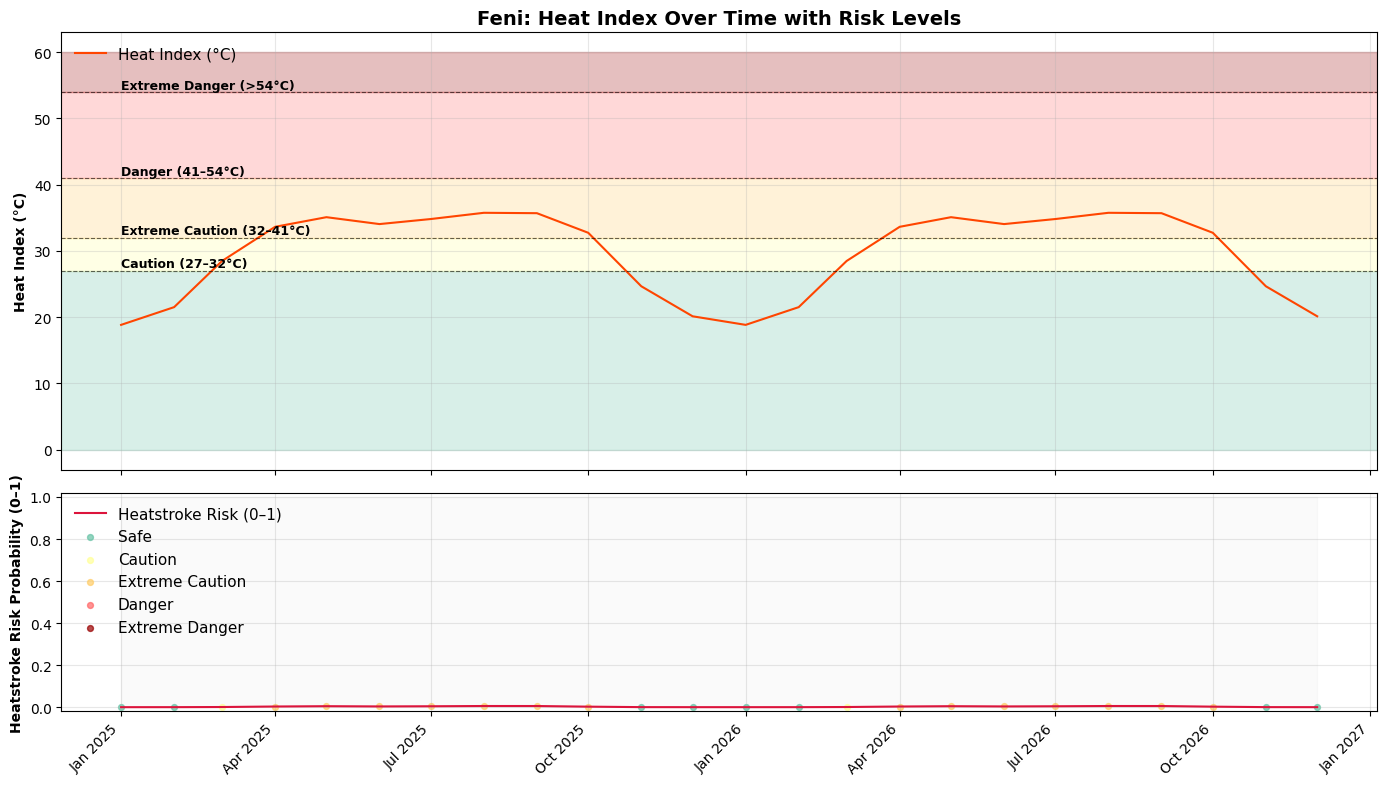

In [78]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# --- Convert date column ---
df_heatstress['date'] = pd.to_datetime(df_heatstress['date'])

# --- Categorize Heat Severity based on NOAA thresholds ---
def categorize_risk(hi_c):
    if hi_c > 54:           # Extreme danger (>54°C)
        return 'Extreme Danger'
    elif hi_c > 41:         # Danger (41–54°C)
        return 'Danger'
    elif hi_c > 32:         # Extreme caution (32–41°C)
        return 'Extreme Caution'
    elif hi_c > 27:         # Caution (27–32°C)
        return 'Caution'
    else:
        return 'Safe'

df_heatstress['Heat_Severity'] = df_heatstress['heat_index_C'].apply(categorize_risk)

# --- Color palette for categories ---
palette = {
    'Safe':'#66c2a5',              # Green
    'Caution':'#ffff99',           # Yellow
    'Extreme Caution':'#ffcc66',   # Orange
    'Danger':'#ff6666',            # Red
    'Extreme Danger':'#990000'     # Dark Red
}

# --- Plot setup ---
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,8), sharex=True, gridspec_kw={'height_ratios':[2,1]})
plt.rcParams.update({'font.size': 11})

# --- Heat Index plot (ax1) ---
ax1.plot(df_heatstress['date'], df_heatstress['heat_index_C'], color='orangered', lw=1.5, label='Heat Index (°C)')

# --- Add NOAA heat index bands as shaded background ---
bands = [
    (0, 27, '#66c2a5', 'Safe (<27°C)'),
    (27, 32, '#ffff99', 'Caution (27–32°C)'),
    (32, 41, '#ffcc66', 'Extreme Caution (32–41°C)'),
    (41, 54, '#ff6666', 'Danger (41–54°C)'),
    (54, 60, '#990000', 'Extreme Danger (>54°C)')
]

for start, end, color, label in bands:
    ax1.axhspan(start, end, color=color, alpha=0.25)

# --- Add threshold lines and labels ---
for start, end, color, label in bands[1:]:
    ax1.axhline(start, color='k', lw=0.8, ls='--', alpha=0.6)
    ax1.text(df_heatstress['date'].iloc[0], start + 0.5, label, fontsize=9, color='k', weight='bold')

ax1.set_ylabel('Heat Index (°C)', weight='bold')
ax1.set_title(f'{district}: Heat Index Over Time with Risk Levels', weight='bold', fontsize=14)
ax1.grid(alpha=0.3)
ax1.legend(loc='upper left', frameon=False)

# --- Heatstroke risk plot (ax2) ---
ax2.fill_between(df_heatstress['date'], 0, 1, color='lightgrey', alpha=0.1)  # subtle background
ax2.plot(df_heatstress['date'], df_heatstress['heatstroke_risk'], color='crimson', lw=1.5, label='Heatstroke Risk (0–1)')

# Color-coded scatter points
for severity, color in palette.items():
    subset = df_heatstress[df_heatstress['Heat_Severity'] == severity]
    ax2.scatter(subset['date'], subset['heatstroke_risk'], s=18, color=color, label=severity, alpha=0.7)

ax2.set_ylabel('Heatstroke Risk Probability (0–1)', weight='bold')
ax2.set_ylim(-0.02,1.02)
ax2.grid(alpha=0.3)
ax2.legend(loc='upper left', frameon=False)

# --- X-axis formatting ---
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()